# NB12 — Final Results Consolidation and Dissertation Evidence Pack

**Dissertation:** Explainable and Trustworthy Multimodal Deep Learning for Predictive Maintenance of Industrial Assets  
**Student:** 2023AA05069  
**Dataset:** NASA C-MAPSS FD001  
**Notebook role:** Final evidence consolidation only — **no model training and no access to raw test labels**

## Purpose

At this stage, the experimental work is complete. In this notebook, I consolidate the evidence generated in NB01–NB11 into one authoritative final-phase evidence pack for the dissertation report.

The notebook does not train, tune or reload any model. It reads only previously saved result artefacts, validates their consistency, creates report-ready tables and figures, maps the evidence to RQ1–RQ4, and records claims together with their necessary qualifications.

## Evidence hierarchy

**Primary evidence**

1. Repeated engine-grouped validation across split seeds 21, 42 and 84 from NB10.
2. One-time official FD001 endpoint evaluation from NB11 under the capped-RUL formulation.

**Supporting evidence**

- Historical seed-42 window-aligned comparison from NB06.
- `cycle_index` ablation and per-engine analysis from NB10.

**Model-behaviour evidence**

- Feature importance, SHAP, view masking and local cases from NB07.
- Noise, masking, RUL-region, bias, stability and exploratory MC Dropout checks from NB08.

The historical seed-42 result is retained for traceability, but the repeated-validation and independent-test results are the primary basis for final claims.


## Section 1 — Setup and project-root resolution

The notebook can be run from the project root or from the `notebooks/` directory. Set `PROJECT_ROOT_OVERRIDE` only when automatic discovery does not locate the repository.


In [1]:
from __future__ import annotations

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 180)

PROJECT_ROOT_OVERRIDE = None  # Example: Path('/path/to/dissertation-rul-xai')


def find_project_root(override=None):
    candidates = []
    if override is not None:
        candidates.append(Path(override).expanduser().resolve())

    cwd = Path.cwd().resolve()
    candidates.extend([
        cwd,
        cwd.parent,
        Path('/content/drive/MyDrive/Dissertation/Project/dissertation-rul-xai'),
        Path.home() / 'dissertation-rul-xai',
    ])

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / 'reports').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate

    raise FileNotFoundError(
        'Could not locate the dissertation project root. '
        'Set PROJECT_ROOT_OVERRIDE to the dissertation-rul-xai directory.'
    )


PROJECT_ROOT = find_project_root(PROJECT_ROOT_OVERRIDE)
FINAL_VALIDATION_DIR = PROJECT_ROOT / 'reports' / 'final_validation'
FINAL_TEST_DIR = PROJECT_ROOT / 'reports' / 'final_test'
FINAL_SUMMARY_DIR = PROJECT_ROOT / 'reports' / 'final_summary'
FINAL_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

print('Project root       :', PROJECT_ROOT)
print('Final validation   :', FINAL_VALIDATION_DIR)
print('Final test         :', FINAL_TEST_DIR)
print('Final summary      :', FINAL_SUMMARY_DIR)


Project root       : /Users/I339667/Library/CloudStorage/OneDrive-SAPSE/Documents/Personal/BITS/FinalSem/Dissertation/Project/dissertation-rul-xai
Final validation   : /Users/I339667/Library/CloudStorage/OneDrive-SAPSE/Documents/Personal/BITS/FinalSem/Dissertation/Project/dissertation-rul-xai/reports/final_validation
Final test         : /Users/I339667/Library/CloudStorage/OneDrive-SAPSE/Documents/Personal/BITS/FinalSem/Dissertation/Project/dissertation-rul-xai/reports/final_test
Final summary      : /Users/I339667/Library/CloudStorage/OneDrive-SAPSE/Documents/Personal/BITS/FinalSem/Dissertation/Project/dissertation-rul-xai/reports/final_summary


## Section 2 — Source artefact registry

Every source used by NB12 is declared here. The notebook fails before consolidation if a required source is absent. This prevents report tables from being assembled from memory or manually copied numbers.


In [2]:
SOURCE_PATHS = {
    # Historical reference
    'historical_comparison': PROJECT_ROOT / 'reports/metrics/multiview_vs_baselines_comparison_fd001.csv',

    # NB10: repeated validation and ablation
    'repeated_split': FINAL_VALIDATION_DIR / 'repeated_validation_split_metrics_fd001.csv',
    'repeated_summary': FINAL_VALIDATION_DIR / 'repeated_validation_summary_fd001.csv',
    'pairwise_comparison': FINAL_VALIDATION_DIR / 'repeated_validation_pairwise_comparison_fd001.csv',
    'fusion_comparison': FINAL_VALIDATION_DIR / 'repeated_validation_fusion_comparison_fd001.csv',
    'per_engine': FINAL_VALIDATION_DIR / 'per_engine_validation_metrics_fd001.csv',
    'cycle_index_ablation': FINAL_VALIDATION_DIR / 'cycle_index_ablation_fd001.csv',
    'nb10_config': FINAL_VALIDATION_DIR / 'frozen_experiment_config.json',

    # NB11: final refit and official test
    'test_metrics': FINAL_TEST_DIR / 'final_test_endpoint_metrics_fd001.csv',
    'test_predictions': FINAL_TEST_DIR / 'final_test_endpoint_predictions_fd001.csv',
    'epoch_selection': FINAL_TEST_DIR / 'final_epoch_selection_fd001.csv',
    'test_protocol': FINAL_TEST_DIR / 'frozen_official_test_protocol.json',
    'pretest_manifest': FINAL_TEST_DIR / 'pretest_freeze_manifest.json',
    'test_manifest': FINAL_TEST_DIR / 'official_test_evaluation_manifest.json',

    # NB07: explainability
    'feature_importance': PROJECT_ROOT / 'reports/explainability/xgboost_feature_importance_fd001.csv',
    'shap_ranking': PROJECT_ROOT / 'reports/explainability/xgboost_shap_feature_ranking_fd001.csv',
    'view_masking': PROJECT_ROOT / 'reports/explainability/multiview_view_masking_explainability_fd001.csv',
    'local_cases': PROJECT_ROOT / 'reports/explainability/local_prediction_cases_multiview_fd001.csv',

    # NB08: trustworthiness
    'robustness': PROJECT_ROOT / 'reports/robustness/robustness_summary_multiview_fd001.csv',
    'rul_range': PROJECT_ROOT / 'reports/robustness/rul_range_error_analysis_multiview_fd001.csv',
    'bias': PROJECT_ROOT / 'reports/robustness/prediction_bias_summary_multiview_fd001.csv',
    'noise_stability': PROJECT_ROOT / 'reports/robustness/repeated_noise_stability_summary_multiview_fd001.csv',
    'uncertainty': PROJECT_ROOT / 'reports/robustness/mc_dropout_uncertainty_summary_multiview_fd001.csv',
}

missing_sources = [str(path) for path in SOURCE_PATHS.values() if not path.is_file()]
if missing_sources:
    raise FileNotFoundError(
        'NB12 cannot run because required source artefacts are missing:\n- '
        + '\n- '.join(missing_sources)
    )

print(f'All {len(SOURCE_PATHS)} required source artefacts are present.')


All 23 required source artefacts are present.


In [3]:
def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def require_columns(df: pd.DataFrame, required: set[str], name: str) -> None:
    missing = required.difference(df.columns)
    if missing:
        raise AssertionError(f'{name} is missing required columns: {sorted(missing)}')


def assert_close(actual, expected, label, atol=1e-6, rtol=1e-6):
    if not np.isclose(actual, expected, atol=atol, rtol=rtol, equal_nan=True):
        raise AssertionError(f'{label}: actual={actual}, expected={expected}')


source_hashes = {name: sha256_file(path) for name, path in SOURCE_PATHS.items()}
source_registry = pd.DataFrame([
    {
        'source_key': name,
        'relative_path': str(path.relative_to(PROJECT_ROOT)),
        'sha256': source_hashes[name],
        'status': 'Present',
    }
    for name, path in SOURCE_PATHS.items()
])

display(source_registry)


,source_key,relative_path,sha256,status
0,historical_comparison,reports/metrics/multiview_vs_baselines_comparison_fd001.csv,054a8ec87c91e79640c2cd9ce05c1f3d54b381bbfa33689c27076f203ab17d35,Present
1,repeated_split,reports/final_validation/repeated_validation_split_metrics_fd001.csv,4e306fce505abf7c2224620d5b92072761e41711ad0f0288e225cc86f6b09829,Present
2,repeated_summary,reports/final_validation/repeated_validation_summary_fd001.csv,004940ef6d06fa7636bf36ca272a2ae2a8e56dc1ef97ce25ca5b6475110b82c1,Present
3,pairwise_comparison,reports/final_validation/repeated_validation_pairwise_comparison_fd001.csv,dd053ae926d2ba7873faddb77ac4cd29c39766415d7c88f06caf2a51f04f4135,Present
4,fusion_comparison,reports/final_validation/repeated_validation_fusion_comparison_fd001.csv,2b9e28204a41cc9087e2397b7e688afeb8c86df491aea6c020874dcdecabd952,Present
5,per_engine,reports/final_validation/per_engine_validation_metrics_fd001.csv,738f5dc10fdf8dc8a862d2d7be8f60050ba7fbddc6857f8f8761bd76682f19aa,Present
6,cycle_index_ablation,reports/final_validation/cycle_index_ablation_fd001.csv,c441ab95cc044cc5736e7309dd29f869bed40b511415f91dca3f8630667aadeb,Present
7,nb10_config,reports/final_validation/frozen_experiment_config.json,59fd7c3c77c297368085fa8d6a070e56848e1c5f53adb3215f61e6352c7ff5fe,Present
8,test_metrics,reports/final_test/final_test_endpoint_metrics_fd001.csv,9375d1f8d2b58430fff38a5149078499a78e6b4b052d7408862f09a210b1ffd8,Present
9,test_predictions,reports/final_test/final_test_endpoint_predictions_fd001.csv,8f4c0dacb227c0846493c67a9b32073877897755c9644ac907ae70d2c4baaaef,Present


## Section 3 — Load and validate primary predictive evidence

The validation checks below independently recompute key summaries from lower-level prediction or split files. The aim is to confirm that NB12 is consolidating internally consistent artefacts rather than merely reproducing their saved text.


In [4]:
historical_df = pd.read_csv(SOURCE_PATHS['historical_comparison'])
repeated_split_df = pd.read_csv(SOURCE_PATHS['repeated_split'])
repeated_summary_df = pd.read_csv(SOURCE_PATHS['repeated_summary'])
pairwise_df = pd.read_csv(SOURCE_PATHS['pairwise_comparison'])
fusion_comparison_df = pd.read_csv(SOURCE_PATHS['fusion_comparison'])
per_engine_df = pd.read_csv(SOURCE_PATHS['per_engine'])
ablation_df = pd.read_csv(SOURCE_PATHS['cycle_index_ablation'])
test_metrics_df = pd.read_csv(SOURCE_PATHS['test_metrics'])
test_predictions_df = pd.read_csv(SOURCE_PATHS['test_predictions'])
epoch_selection_df = pd.read_csv(SOURCE_PATHS['epoch_selection'])

with SOURCE_PATHS['nb10_config'].open() as f:
    nb10_config = json.load(f)
with SOURCE_PATHS['test_protocol'].open() as f:
    test_protocol = json.load(f)
with SOURCE_PATHS['pretest_manifest'].open() as f:
    pretest_manifest = json.load(f)
with SOURCE_PATHS['test_manifest'].open() as f:
    test_manifest = json.load(f)

require_columns(historical_df, {
    'model_group', 'model', 'feature_or_views',
    'validation_rmse', 'validation_mae', 'validation_r2'
}, 'historical comparison')
require_columns(repeated_split_df, {
    'split_seed', 'model_seed', 'model', 'validation_rmse', 'validation_mae',
    'validation_r2', 'macro_engine_rmse', 'best_epoch', 'mean_error'
}, 'repeated split metrics')
require_columns(repeated_summary_df, {
    'model', 'n_splits', 'mean_rmse', 'std_rmse', 'mean_mae', 'mean_r2',
    'mean_macro_eng_rmse', 'mean_error_mean', 'best_epochs'
}, 'repeated summary')
require_columns(per_engine_df, {
    'model', 'split_seed', 'unit_number', 'n_windows',
    'engine_rmse', 'engine_mae', 'mean_error'
}, 'per-engine metrics')
require_columns(ablation_df, {
    'split_seed', 'model', 'rmse_with_ci', 'rmse_without_ci',
    'rmse_delta', 'rmse_delta_pct', 'control_source'
}, 'cycle_index ablation')
require_columns(test_metrics_df, {
    'model', 'n_test_engines', 'rmse', 'mae', 'r2', 'mean_error'
}, 'official test metrics')
require_columns(test_predictions_df, {
    'unit_number', 'last_observed_cycle', 'RUL_official_uncapped', 'RUL_capped'
}, 'official test predictions')
require_columns(epoch_selection_df, {
    'model', 'seed_21_best_epoch', 'seed_42_best_epoch', 'seed_84_best_epoch',
    'selection_rule', 'final_epoch'
}, 'epoch selection')

PRINCIPAL_MODELS = ['XGBoost', 'GRU', 'DerivedOnlyMLP', 'MultiViewGRUFusion']
SPLIT_SEEDS = [21, 42, 84]

assert set(repeated_split_df['model']) == set(PRINCIPAL_MODELS)
assert sorted(repeated_split_df['split_seed'].unique().tolist()) == SPLIT_SEEDS
assert len(repeated_split_df) == 12
assert repeated_split_df.groupby(['split_seed', 'model']).size().eq(1).all()
assert repeated_split_df['model_seed'].dropna().eq(42).all()

assert set(repeated_summary_df['model']) == set(PRINCIPAL_MODELS)
assert repeated_summary_df['n_splits'].eq(3).all()

assert len(per_engine_df) == 240
assert per_engine_df.groupby(['split_seed', 'model'])['unit_number'].nunique().eq(20).all()

assert set(ablation_df['model']) == {'XGBoost', 'DerivedOnlyMLP', 'MultiViewGRUFusion'}
assert ablation_df['split_seed'].eq(42).all()
assert ablation_df['control_source'].eq('final-protocol seed 42').all()

assert set(test_metrics_df['model']) == set(PRINCIPAL_MODELS)
assert test_metrics_df['n_test_engines'].eq(100).all()
assert len(test_predictions_df) == 100
assert test_predictions_df['unit_number'].nunique() == 100
assert not test_predictions_df['unit_number'].duplicated().any()

assert set(epoch_selection_df['model']) == {'GRU', 'DerivedOnlyMLP', 'MultiViewGRUFusion'}

print('Primary predictive evidence loaded and structural assertions passed.')


Primary predictive evidence loaded and structural assertions passed.


In [5]:
# Recompute NB10 mean and sample-standard-deviation metrics from split-level evidence.
recomputed_summary = (
    repeated_split_df.groupby('model', as_index=False)
    .agg(
        mean_rmse=('validation_rmse', 'mean'),
        std_rmse=('validation_rmse', lambda s: s.std(ddof=1)),
        mean_mae=('validation_mae', 'mean'),
        std_mae=('validation_mae', lambda s: s.std(ddof=1)),
        mean_r2=('validation_r2', 'mean'),
        std_r2=('validation_r2', lambda s: s.std(ddof=1)),
        mean_macro_eng_rmse=('macro_engine_rmse', 'mean'),
        std_macro_eng_rmse=('macro_engine_rmse', lambda s: s.std(ddof=1)),
        mean_error_mean=('mean_error', 'mean'),
        mean_error_std=('mean_error', lambda s: s.std(ddof=1)),
    )
)

summary_check = repeated_summary_df.merge(
    recomputed_summary,
    on='model',
    suffixes=('_saved', '_recomputed'),
    validate='one_to_one',
)

for metric in [
    'mean_rmse', 'std_rmse', 'mean_mae', 'std_mae', 'mean_r2', 'std_r2',
    'mean_macro_eng_rmse', 'std_macro_eng_rmse', 'mean_error_mean', 'mean_error_std'
]:
    for _, row in summary_check.iterrows():
        # NB10 summary is rounded to four decimals.
        assert_close(
            row[f'{metric}_saved'],
            row[f'{metric}_recomputed'],
            f'{row["model"]} {metric}',
            atol=5e-4,
            rtol=0,
        )

# Recompute NB11 metrics from endpoint predictions.
for model in PRINCIPAL_MODELS:
    pred_col = f'{model}_prediction'
    err_col = f'{model}_error'
    require_columns(test_predictions_df, {pred_col, err_col}, f'{model} predictions')

    y = test_predictions_df['RUL_capped'].to_numpy(dtype=float)
    pred = test_predictions_df[pred_col].to_numpy(dtype=float)
    err = pred - y

    saved = test_metrics_df.loc[test_metrics_df['model'].eq(model)].iloc[0]
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    r2 = float(1 - np.sum(err ** 2) / np.sum((y - y.mean()) ** 2))
    mean_error = float(err.mean())

    assert_close(rmse, saved['rmse'], f'{model} test RMSE')
    assert_close(mae, saved['mae'], f'{model} test MAE')
    assert_close(r2, saved['r2'], f'{model} test R2')
    assert_close(mean_error, saved['mean_error'], f'{model} test mean error')
    assert np.allclose(err, test_predictions_df[err_col].to_numpy(dtype=float), atol=1e-6)

# Confirm the frozen epoch rule.
for _, row in epoch_selection_df.iterrows():
    seeds = [row['seed_21_best_epoch'], row['seed_42_best_epoch'], row['seed_84_best_epoch']]
    expected_epoch = int(np.median(seeds))
    assert int(row['final_epoch']) == expected_epoch

expected_epochs = {'GRU': 12, 'DerivedOnlyMLP': 59, 'MultiViewGRUFusion': 12}
actual_epochs = epoch_selection_df.set_index('model')['final_epoch'].astype(int).to_dict()
assert actual_epochs == expected_epochs

uncapped_above_cap = int((test_predictions_df['RUL_official_uncapped'] > 125).sum())
assert uncapped_above_cap == 11

print('Independent numerical checks passed.')
print('Frozen epochs:', actual_epochs)
print('Official endpoint targets above cap 125:', uncapped_above_cap)


Independent numerical checks passed.
Frozen epochs: {'GRU': 12, 'DerivedOnlyMLP': 59, 'MultiViewGRUFusion': 12}
Official endpoint targets above cap 125: 11


## Section 4 — Table F1: Experimental protocol summary

This table records the frozen task definition and evaluation protocol so that the final results are interpreted on the correct population and target definition.


In [6]:
protocol_rows = [
    ('Dataset', 'NASA C-MAPSS FD001', '100 train engines and 100 official test engines; one operating condition and one fault mode'),
    ('Prediction task', 'Regression', 'Remaining Useful Life in cycles'),
    ('Target formulation', 'Capped RUL', 'RUL capped at 125 cycles'),
    ('Sequence window', '30 cycles', 'One 30-cycle sensor window per training sample'),
    ('Raw sequence view', '30 × 14', 'Fourteen variable sensor measurements'),
    ('Derived view', '43 features', '14 rolling means, 14 rolling standard deviations, 14 deltas and cycle_index'),
    ('Rolling window', '5 cycles', 'Computed within engine using current and preceding cycles only'),
    ('Validation grouping', 'Engine-level', 'No engine overlap between training and validation'),
    ('Repeated-validation split seeds', '21, 42, 84', 'Model seed fixed at 42'),
    ('Repeated-validation unit', 'Eligible windows', 'Metrics are window-weighted; macro-engine RMSE is also reported'),
    ('Final training', 'All 100 training engines', 'No validation set and no early stopping during final refit'),
    ('Neural final epochs', 'GRU 12; DerivedOnlyMLP 59; Fusion 12', 'Median best epoch across the three final-protocol validation splits'),
    ('Official test unit', 'One endpoint per engine', 'Exactly 100 endpoint predictions per model'),
    ('Official test target', 'Official endpoint RUL capped at 125', 'Predictions clipped to [0, 125]'),
    ('Test-use rule', 'Evaluated once', 'No tuning after viewing official test outcomes'),
    ('Principal metrics', 'RMSE, MAE and R²', 'Mean error and supporting error statistics also reported'),
]

protocol_df = pd.DataFrame(protocol_rows, columns=['protocol_item', 'frozen_value', 'qualification'])
protocol_path = FINAL_SUMMARY_DIR / 'experimental_protocol_summary_fd001.csv'
protocol_df.to_csv(protocol_path, index=False)
display(protocol_df)


,protocol_item,frozen_value,qualification
0,Dataset,NASA C-MAPSS FD001,100 train engines and 100 official test engines; one operating condition and one fault mode
1,Prediction task,Regression,Remaining Useful Life in cycles
2,Target formulation,Capped RUL,RUL capped at 125 cycles
3,Sequence window,30 cycles,One 30-cycle sensor window per training sample
4,Raw sequence view,30 × 14,Fourteen variable sensor measurements
5,Derived view,43 features,"14 rolling means, 14 rolling standard deviations, 14 deltas and cycle_index"
6,Rolling window,5 cycles,Computed within engine using current and preceding cycles only
7,Validation grouping,Engine-level,No engine overlap between training and validation
8,Repeated-validation split seeds,"21, 42, 84",Model seed fixed at 42
9,Repeated-validation unit,Eligible windows,Metrics are window-weighted; macro-engine RMSE is also reported


## Section 5 — Table F2: Historical seed-42 reference

The historical seed-42 result remains part of the evidence trail, but it is not used as the three-split repeated-validation result. It provides continuity with the mid-semester submission and shows why repeated validation was required.


In [7]:
historical_report_df = historical_df.rename(columns={
    'feature_or_views': 'input_representation',
    'validation_rmse': 'rmse',
    'validation_mae': 'mae',
    'validation_r2': 'r2',
}).copy()
historical_report_df['evidence_role'] = 'Historical seed-42 window-aligned reference'
historical_report_df['qualification'] = (
    'Single engine-level split; retained for traceability and not treated as repeated-validation evidence'
)
historical_report_df = historical_report_df[
    ['model_group', 'model', 'input_representation', 'rmse', 'mae', 'r2', 'evidence_role', 'qualification']
].sort_values('rmse').reset_index(drop=True)

historical_path = FINAL_SUMMARY_DIR / 'seed42_historical_reference_fd001.csv'
historical_report_df.to_csv(historical_path, index=False)
display(historical_report_df)


,model_group,model,input_representation,rmse,mae,r2,evidence_role,qualification
0,Multi-view Deep Learning,MultiViewGRUFusion,sensor_sequence_view + derived_degradation_view,12.0657,8.9406,0.9168,Historical seed-42 window-aligned reference,Single engine-level split; retained for traceability and not treated as repeated-validation evidence
1,Classical,XGBoost,C,12.4894,9.2675,0.9109,Historical seed-42 window-aligned reference,Single engine-level split; retained for traceability and not treated as repeated-validation evidence
2,Multi-view Deep Learning,DerivedOnlyMLP,derived_degradation_view,13.1451,9.4204,0.9013,Historical seed-42 window-aligned reference,Single engine-level split; retained for traceability and not treated as repeated-validation evidence
3,Deep Learning,GRU,B (window=30),13.1605,9.7182,0.9010,Historical seed-42 window-aligned reference,Single engine-level split; retained for traceability and not treated as repeated-validation evidence
4,Deep Learning,CNN1D,B (window=30),18.1509,14.0382,0.8118,Historical seed-42 window-aligned reference,Single engine-level split; retained for traceability and not treated as repeated-validation evidence


## Section 6 — Tables F3–F7: Repeated validation, fusion comparison, ablation and per-engine analysis

The standard deviations below are descriptive sample standard deviations across three split configurations. They are not inferential confidence intervals.


In [8]:
# F3 — split-level results
f3_split_df = repeated_split_df.copy().sort_values(['split_seed', 'validation_rmse']).reset_index(drop=True)
f3_path = FINAL_SUMMARY_DIR / 'repeated_validation_split_report_fd001.csv'
f3_split_df.to_csv(f3_path, index=False)

# F4 — report-ready mean ± sample standard deviation summary
f4_summary_df = repeated_summary_df.copy()
f4_summary_df['rmse_mean_std'] = f4_summary_df.apply(
    lambda r: f"{r['mean_rmse']:.4f} ± {r['std_rmse']:.4f}", axis=1
)
f4_summary_df['mae_mean_std'] = f4_summary_df.apply(
    lambda r: f"{r['mean_mae']:.4f} ± {r['std_mae']:.4f}", axis=1
)
f4_summary_df['r2_mean_std'] = f4_summary_df.apply(
    lambda r: f"{r['mean_r2']:.4f} ± {r['std_r2']:.4f}", axis=1
)
f4_summary_df['macro_engine_rmse_mean_std'] = f4_summary_df.apply(
    lambda r: f"{r['mean_macro_eng_rmse']:.4f} ± {r['std_macro_eng_rmse']:.4f}", axis=1
)
f4_summary_df['validation_rank'] = f4_summary_df['mean_rmse'].rank(method='min').astype(int)
f4_summary_df['interpretation'] = np.where(
    f4_summary_df['model'].eq('DerivedOnlyMLP'),
    'Lowest mean validation RMSE and MAE across the three split configurations',
    np.where(
        f4_summary_df['model'].eq('MultiViewGRUFusion'),
        'Competitive mean RMSE, but higher variability and no consistent split-level superiority',
        'Comparator model in the repeated-validation analysis'
    )
)
f4_summary_df = f4_summary_df.sort_values('mean_rmse').reset_index(drop=True)

f4_report_cols = [
    'validation_rank', 'model', 'rmse_mean_std', 'mae_mean_std', 'r2_mean_std',
    'macro_engine_rmse_mean_std', 'mean_error_mean', 'best_epochs', 'interpretation'
]
f4_report_path = FINAL_SUMMARY_DIR / 'repeated_validation_report_table_fd001.csv'
f4_summary_df[f4_report_cols].to_csv(f4_report_path, index=False)

# F5 — focused fusion comparisons and win counts
f5_fusion_df = fusion_comparison_df.copy()
f5_path = FINAL_SUMMARY_DIR / 'fusion_comparison_report_fd001.csv'
f5_fusion_df.to_csv(f5_path, index=False)

# F6 — cycle_index ablation
f6_ablation_df = ablation_df.copy().sort_values('rmse_delta_pct', ascending=False).reset_index(drop=True)
f6_ablation_df['interpretation'] = (
    'Positive RMSE delta means performance worsened after removing cycle_index; '
    'this measures lifecycle-position dependence and does not by itself establish target leakage.'
)
f6_path = FINAL_SUMMARY_DIR / 'cycle_index_ablation_report_fd001.csv'
f6_ablation_df.to_csv(f6_path, index=False)

# F7 — per-engine summary
engine_distribution_df = (
    per_engine_df.groupby('model', as_index=False)
    .agg(
        engine_appearances=('unit_number', 'size'),
        mean_engine_rmse=('engine_rmse', 'mean'),
        median_engine_rmse=('engine_rmse', 'median'),
        std_engine_rmse=('engine_rmse', lambda s: s.std(ddof=1)),
        p90_engine_rmse=('engine_rmse', lambda s: s.quantile(0.90)),
        mean_engine_mae=('engine_mae', 'mean'),
        mean_engine_bias=('mean_error', 'mean'),
        mean_windows_per_engine=('n_windows', 'mean'),
    )
)

f7_per_engine_df = repeated_summary_df[[
    'model', 'mean_rmse', 'mean_macro_eng_rmse'
]].merge(engine_distribution_df, on='model', validate='one_to_one')
f7_per_engine_df = f7_per_engine_df.rename(columns={
    'mean_rmse': 'mean_window_weighted_rmse',
    'mean_macro_eng_rmse': 'mean_split_macro_engine_rmse',
})
f7_per_engine_df['macro_minus_window_weighted_rmse'] = (
    f7_per_engine_df['mean_split_macro_engine_rmse'] - f7_per_engine_df['mean_window_weighted_rmse']
)
f7_per_engine_df = f7_per_engine_df.sort_values('mean_window_weighted_rmse').reset_index(drop=True)
f7_path = FINAL_SUMMARY_DIR / 'per_engine_report_table_fd001.csv'
f7_per_engine_df.to_csv(f7_path, index=False)

print('F3 — Split-level repeated validation')
display(f3_split_df)
print('F4 — Repeated-validation summary')
display(f4_summary_df[f4_report_cols])
print('F5 — Fusion comparison')
display(f5_fusion_df)
print('F6 — cycle_index ablation')
display(f6_ablation_df)
print('F7 — Per-engine summary')
display(f7_per_engine_df)


F3 — Split-level repeated validation


,split_seed,model_seed,model,validation_rmse,validation_mae,validation_r2,macro_engine_rmse,best_epoch,mean_error
0,21,42,DerivedOnlyMLP,14.015839,9.977811,0.886541,13.510664,55.0,0.546526
1,21,42,XGBoost,14.112880,9.948947,0.884964,13.457154,NaN,0.158539
2,21,42,GRU,14.504371,11.142962,0.878493,14.359249,12.0,-1.350133
3,21,42,MultiViewGRUFusion,14.513174,10.787430,0.878346,14.000737,12.0,-3.561232
4,42,42,XGBoost,12.534080,9.317050,0.910240,12.227686,NaN,-2.256899
5,42,42,MultiViewGRUFusion,12.563174,9.157431,0.909823,12.301750,9.0,-1.811220
6,42,42,DerivedOnlyMLP,13.440774,9.655815,0.896784,13.142025,60.0,-0.171109
7,42,42,GRU,14.028483,10.956527,0.887561,13.877424,12.0,-1.482138
8,84,42,GRU,14.868404,11.532914,0.873973,14.608336,26.0,-2.979907
9,84,42,DerivedOnlyMLP,15.235867,11.072456,0.867667,14.436115,59.0,-1.302489


F4 — Repeated-validation summary


,validation_rank,model,rmse_mean_std,mae_mean_std,r2_mean_std,macro_engine_rmse_mean_std,mean_error_mean,best_epochs,interpretation
0,1,DerivedOnlyMLP,14.2308 ± 0.9167,10.2354 ± 0.7426,0.8837 ± 0.0148,13.6963 ± 0.6667,-0.3090,"[55.0, 60.0, 59.0]",Lowest mean validation RMSE and MAE across the three split configurations
1,2,MultiViewGRUFusion,14.2787 ± 1.6112,10.7053 ± 1.5085,0.8822 ± 0.0259,13.6978 ± 1.2719,-3.5229,"[12.0, 9.0, 12.0]","Competitive mean RMSE, but higher variability and no consistent split-level superiority"
2,3,XGBoost,14.4297 ± 2.0723,10.4897 ± 1.5172,0.8791 ± 0.0344,13.7249 ± 1.6475,-1.7722,[],Comparator model in the repeated-validation analysis
3,4,GRU,14.4671 ± 0.4212,11.2108 ± 0.2941,0.8800 ± 0.0069,14.2817 ± 0.3716,-1.9374,"[12.0, 12.0, 26.0]",Comparator model in the repeated-validation analysis


F5 — Fusion comparison


,split_seed,fusion_rmse,XGBoost_rmse,fusion_vs_XGBoost_pct,GRU_rmse,fusion_vs_GRU_pct,DerivedOnlyMLP_rmse,fusion_vs_DerivedOnlyMLP_pct,fusion_wins_vs_XGBoost,fusion_wins_vs_GRU,fusion_wins_vs_DerivedOnlyMLP
0,21,14.5132,14.1129,-2.84,14.5044,-0.06,14.0158,-3.55,1,1,1
1,42,12.5632,12.5341,-0.23,14.0285,10.45,13.4408,6.53,1,1,1
2,84,15.7599,16.6421,5.30,14.8684,-6.00,15.2359,-3.44,1,1,1


F6 — cycle_index ablation


,split_seed,model,rmse_with_ci,rmse_without_ci,rmse_delta,rmse_delta_pct,mae_with_ci,mae_without_ci,mae_delta,r2_with_ci,r2_without_ci,r2_delta,control_source,interpretation
0,42,DerivedOnlyMLP,13.4408,15.6341,2.1933,16.32,9.6558,11.7866,2.1308,0.8968,0.8603,-0.0364,final-protocol seed 42,Positive RMSE delta means performance worsened after removing cycle_index; this measures lifecycle-position dependence and does not by itself establish target leakage.
1,42,MultiViewGRUFusion,12.5632,14.4477,1.8845,15.00,9.1574,10.7726,1.6152,0.9098,0.8807,-0.0291,final-protocol seed 42,Positive RMSE delta means performance worsened after removing cycle_index; this measures lifecycle-position dependence and does not by itself establish target leakage.
2,42,XGBoost,12.5341,13.9673,1.4332,11.43,9.3171,10.4292,1.1121,0.9102,0.8885,-0.0217,final-protocol seed 42,Positive RMSE delta means performance worsened after removing cycle_index; this measures lifecycle-position dependence and does not by itself establish target leakage.


F7 — Per-engine summary


,model,mean_window_weighted_rmse,mean_split_macro_engine_rmse,engine_appearances,mean_engine_rmse,median_engine_rmse,std_engine_rmse,p90_engine_rmse,mean_engine_mae,mean_engine_bias,mean_windows_per_engine,macro_minus_window_weighted_rmse
0,DerivedOnlyMLP,14.2308,13.6963,60,13.696268,11.880644,5.901368,21.834462,10.668557,1.641985,180.7,-0.5345
1,MultiViewGRUFusion,14.2787,13.6978,60,13.697793,11.932562,4.844349,21.042123,10.762821,-1.524793,180.7,-0.5809
2,XGBoost,14.4297,13.7249,60,13.724927,11.540822,6.350823,23.660224,10.843199,0.487239,180.7,-0.7048
3,GRU,14.4671,14.2817,60,14.281670,13.936393,3.623278,17.974069,11.293120,0.173607,180.7,-0.1854


### Repeated-validation interpretation

The final-protocol evidence supports **Outcome C as the primary outcome**, with **Outcome D as an additional observation**:

- Fusion does not consistently outperform the strongest single-view model.
- DerivedOnlyMLP has the lowest mean validation RMSE and MAE.
- The strongest model varies across engine cohorts, so one split would provide an incomplete picture.
- Fusion has a consistent negative mean-error tendency across all three split configurations.


In [9]:
# Identify split winners and fusion win counts directly from saved evidence.
split_winners = (
    repeated_split_df.loc[
        repeated_split_df.groupby('split_seed')['validation_rmse'].idxmin(),
        ['split_seed', 'model', 'validation_rmse']
    ]
    .rename(columns={'model': 'winning_model', 'validation_rmse': 'winning_rmse'})
    .sort_values('split_seed')
    .reset_index(drop=True)
)

fusion_row = repeated_summary_df.loc[repeated_summary_df['model'].eq('MultiViewGRUFusion')].iloc[0]
derived_row = repeated_summary_df.loc[repeated_summary_df['model'].eq('DerivedOnlyMLP')].iloc[0]

print('Split winners:')
display(split_winners)
print(
    f"DerivedOnlyMLP mean RMSE {derived_row['mean_rmse']:.4f}; "
    f"Fusion mean RMSE {fusion_row['mean_rmse']:.4f}."
)
print(
    'Fusion mean error across splits: '
    f"{fusion_row['mean_error_mean']:.4f} cycles (prediction minus actual)."
)


Split winners:


,split_seed,winning_model,winning_rmse
0,21,DerivedOnlyMLP,14.015839
1,42,XGBoost,12.534080
2,84,GRU,14.868404


DerivedOnlyMLP mean RMSE 14.2308; Fusion mean RMSE 14.2787.
Fusion mean error across splits: -3.5229 cycles (prediction minus actual).


## Section 7 — Table F8 and E53: Official test and final model comparison

The validation and test RMSE values are shown together for evidence synthesis, but they are **not treated as a direct generalisation gap** because the evaluation units differ:

- NB10: all eligible validation windows.
- NB11: one final endpoint per official test engine.


In [10]:
# F8 — official test report table
test_report_df = test_metrics_df.copy().sort_values('rmse').reset_index(drop=True)
test_report_df.insert(0, 'test_rank', np.arange(1, len(test_report_df) + 1))
best_test_rmse = float(test_report_df['rmse'].min())
test_report_df['rmse_above_best_pct'] = (
    (test_report_df['rmse'] - best_test_rmse) / best_test_rmse * 100
)
test_report_df['evaluation_unit'] = 'One official endpoint per test engine'
test_report_df['qualification'] = (
    'Official endpoint RUL capped at 125; predictions clipped to [0, 125]; '
    'not directly comparable with uncapped benchmark results'
)
f8_path = FINAL_SUMMARY_DIR / 'final_test_report_table_fd001.csv'
test_report_df.to_csv(f8_path, index=False)

# E53 — authoritative final model comparison
representations = {
    'XGBoost': 'Feature Set C: current sensor values plus derived degradation features (57 inputs)',
    'GRU': 'Raw sensor sequence view (30 × 14)',
    'DerivedOnlyMLP': 'Derived degradation view (43 inputs)',
    'MultiViewGRUFusion': 'Raw sensor sequence (30 × 14) fused with 43 derived features',
}

validation_for_merge = repeated_summary_df.rename(columns={
    'mean_rmse': 'validation_mean_rmse',
    'std_rmse': 'validation_std_rmse',
    'mean_mae': 'validation_mean_mae',
    'std_mae': 'validation_std_mae',
    'mean_r2': 'validation_mean_r2',
    'std_r2': 'validation_std_r2',
    'mean_macro_eng_rmse': 'validation_mean_macro_engine_rmse',
    'mean_error_mean': 'validation_mean_error',
})
validation_for_merge['validation_rank'] = validation_for_merge['validation_mean_rmse'].rank(method='min').astype(int)

test_for_merge = test_metrics_df.rename(columns={
    'rmse': 'official_test_rmse',
    'mae': 'official_test_mae',
    'r2': 'official_test_r2',
    'mean_error': 'official_test_mean_error',
    'median_absolute_error': 'official_test_median_absolute_error',
})
test_for_merge['official_test_rank'] = test_for_merge['official_test_rmse'].rank(method='min').astype(int)

final_model_comparison_df = validation_for_merge.merge(
    test_for_merge,
    on='model',
    validate='one_to_one',
)
final_model_comparison_df.insert(
    1,
    'input_representation',
    final_model_comparison_df['model'].map(representations),
)
final_model_comparison_df['validation_evaluation_unit'] = 'All eligible windows across three engine-grouped splits'
final_model_comparison_df['test_evaluation_unit'] = 'One endpoint for each of 100 official test engines'
final_model_comparison_df['comparability_note'] = (
    'Validation and test rankings may be compared descriptively; absolute RMSE values are not a like-for-like gap measure.'
)

comparison_cols = [
    'model', 'input_representation',
    'validation_rank', 'validation_mean_rmse', 'validation_std_rmse',
    'validation_mean_mae', 'validation_mean_r2', 'validation_mean_macro_engine_rmse',
    'official_test_rank', 'official_test_rmse', 'official_test_mae',
    'official_test_median_absolute_error', 'official_test_r2', 'official_test_mean_error',
    'validation_evaluation_unit', 'test_evaluation_unit', 'comparability_note'
]
final_model_comparison_df = final_model_comparison_df[comparison_cols].sort_values('official_test_rank').reset_index(drop=True)

final_model_path = FINAL_SUMMARY_DIR / 'final_model_comparison_fd001.csv'
final_model_comparison_df.to_csv(final_model_path, index=False)

print('F8 — Official test results')
display(test_report_df)
print('E53 — Final model comparison')
display(final_model_comparison_df)


F8 — Official test results


,test_rank,model,n_test_engines,rmse,mae,median_absolute_error,r2,mean_error,error_std,min_error,max_error,target_definition,prediction_clipping,rmse_above_best_pct,evaluation_unit,qualification
0,1,XGBoost,100,12.245915,9.015458,6.149161,0.906616,0.496625,12.297482,-38.712578,35.298340,official endpoint RUL capped at 125,"[0, 125]",0.000000,One official endpoint per test engine,"Official endpoint RUL capped at 125; predictions clipped to [0, 125]; not directly comparable with uncapped benchmark results"
1,2,DerivedOnlyMLP,100,12.829469,9.558829,7.103100,0.897504,-0.553221,12.882108,-38.622116,30.882683,official endpoint RUL capped at 125,"[0, 125]",4.765297,One official endpoint per test engine,"Official endpoint RUL capped at 125; predictions clipped to [0, 125]; not directly comparable with uncapped benchmark results"
2,3,GRU,100,13.286039,9.916686,7.455414,0.890079,0.760698,13.331067,-38.810429,39.150246,official endpoint RUL capped at 125,"[0, 125]",8.493642,One official endpoint per test engine,"Official endpoint RUL capped at 125; predictions clipped to [0, 125]; not directly comparable with uncapped benchmark results"
3,4,MultiViewGRUFusion,100,13.378219,9.937203,6.879128,0.888548,-3.197101,13.056028,-37.936913,28.314972,official endpoint RUL capped at 125,"[0, 125]",9.246380,One official endpoint per test engine,"Official endpoint RUL capped at 125; predictions clipped to [0, 125]; not directly comparable with uncapped benchmark results"


E53 — Final model comparison


,model,input_representation,validation_rank,validation_mean_rmse,validation_std_rmse,validation_mean_mae,validation_mean_r2,validation_mean_macro_engine_rmse,official_test_rank,official_test_rmse,official_test_mae,official_test_median_absolute_error,official_test_r2,official_test_mean_error,validation_evaluation_unit,test_evaluation_unit,comparability_note
0,XGBoost,Feature Set C: current sensor values plus derived degradation features (57 inputs),3,14.4297,2.0723,10.4897,0.8791,13.7249,1,12.245915,9.015458,6.149161,0.906616,0.496625,All eligible windows across three engine-grouped splits,One endpoint for each of 100 official test engines,Validation and test rankings may be compared descriptively; absolute RMSE values are not a like-for-like gap measure.
1,DerivedOnlyMLP,Derived degradation view (43 inputs),1,14.2308,0.9167,10.2354,0.8837,13.6963,2,12.829469,9.558829,7.103100,0.897504,-0.553221,All eligible windows across three engine-grouped splits,One endpoint for each of 100 official test engines,Validation and test rankings may be compared descriptively; absolute RMSE values are not a like-for-like gap measure.
2,GRU,Raw sensor sequence view (30 × 14),4,14.4671,0.4212,11.2108,0.8800,14.2817,3,13.286039,9.916686,7.455414,0.890079,0.760698,All eligible windows across three engine-grouped splits,One endpoint for each of 100 official test engines,Validation and test rankings may be compared descriptively; absolute RMSE values are not a like-for-like gap measure.
3,MultiViewGRUFusion,Raw sensor sequence (30 × 14) fused with 43 derived features,2,14.2787,1.6112,10.7053,0.8822,13.6978,4,13.378219,9.937203,6.879128,0.888548,-3.197101,All eligible windows across three engine-grouped splits,One endpoint for each of 100 official test engines,Validation and test rankings may be compared descriptively; absolute RMSE values are not a like-for-like gap measure.


### Official-test interpretation

XGBoost is the strongest final held-out model under the dissertation's capped endpoint formulation. DerivedOnlyMLP ranks second, followed by GRU and MultiViewGRUFusion.

This result strengthens the qualified final conclusion: the engineered degradation representation is highly informative, while the current fusion architecture does not reliably improve upon the strongest single-view or classical alternative. This is a valid negative experimental finding, not a reason to restart model development.


## Section 8 — Final predictive figures

These figures are produced only from saved NB10 and NB11 outputs. No predictions are regenerated.


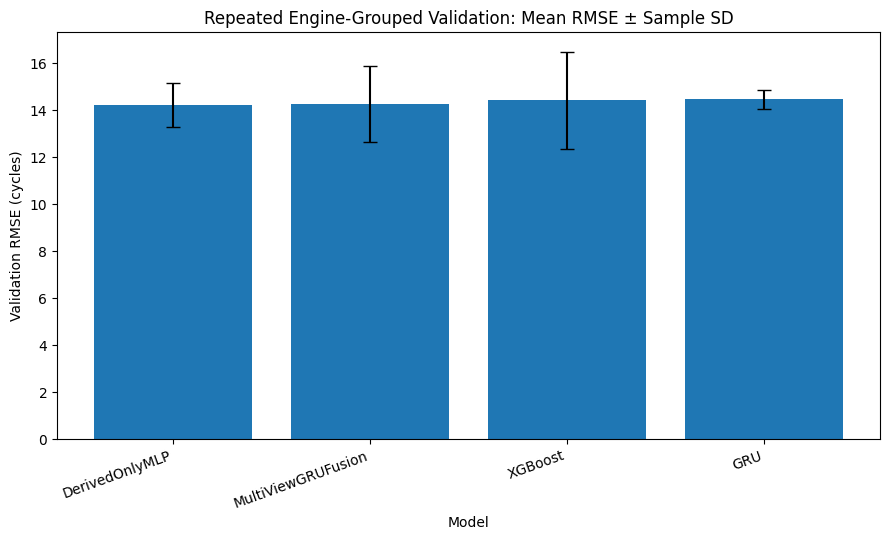

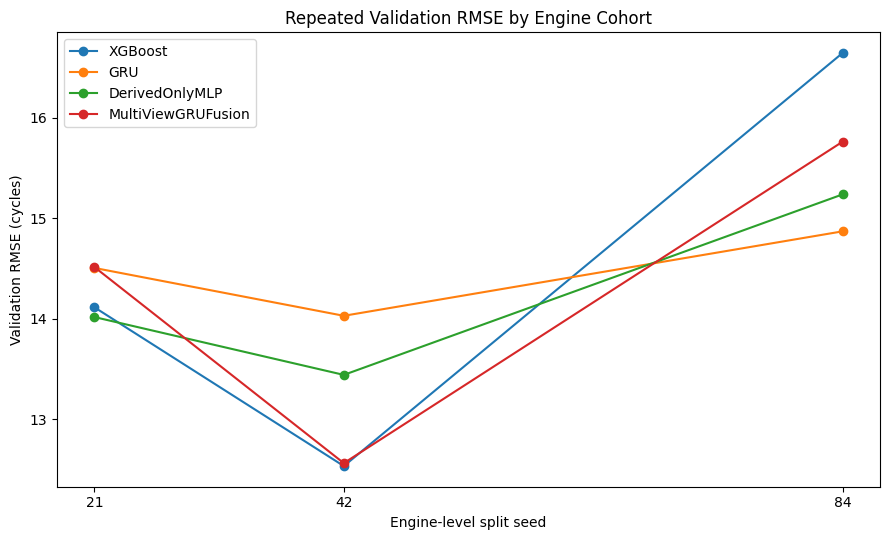

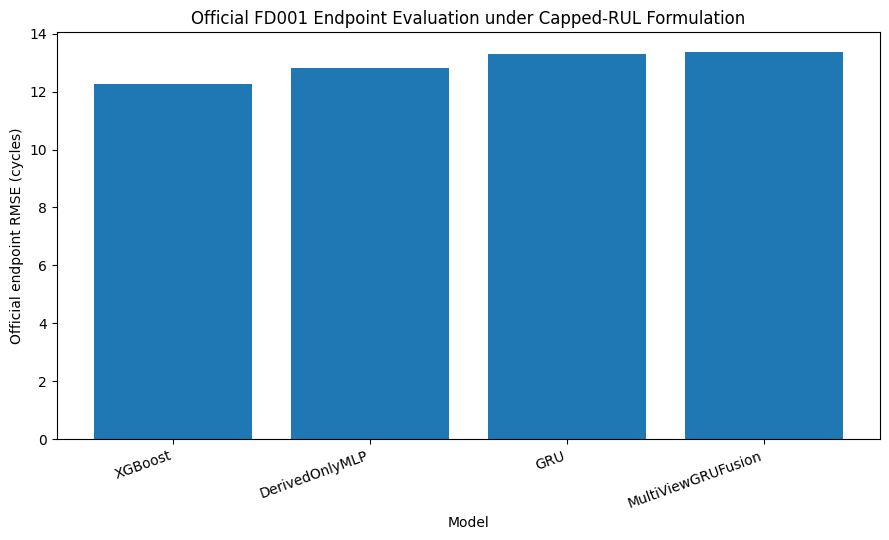

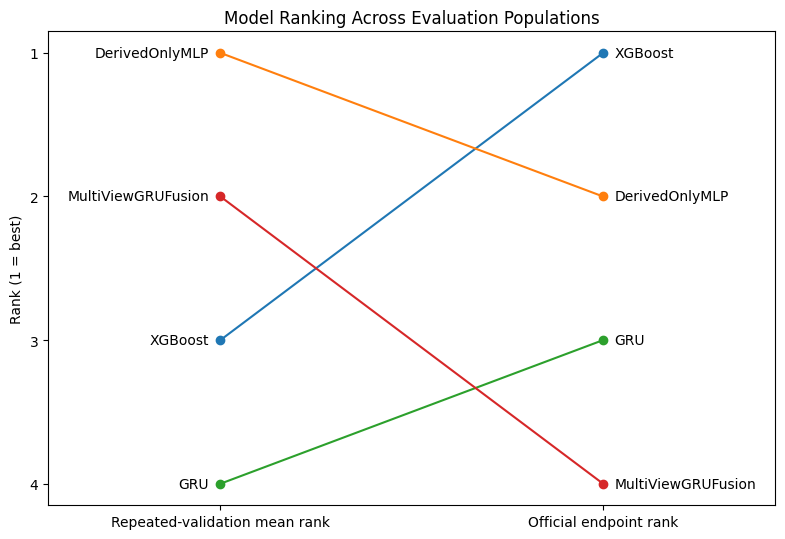

Saved predictive figures:
 - reports/final_summary/repeated_validation_mean_rmse_fd001.png
 - reports/final_summary/repeated_validation_split_rmse_fd001.png
 - reports/final_summary/official_test_rmse_fd001.png
 - reports/final_summary/validation_test_rank_comparison_fd001.png


In [11]:
# Figure 1 — repeated-validation mean RMSE with descriptive sample SD.
plot_df = repeated_summary_df.sort_values('mean_rmse').reset_index(drop=True)
fig_path_validation_mean = FINAL_SUMMARY_DIR / 'repeated_validation_mean_rmse_fd001.png'

plt.figure(figsize=(9, 5.5))
plt.bar(plot_df['model'], plot_df['mean_rmse'], yerr=plot_df['std_rmse'], capsize=5)
plt.ylabel('Validation RMSE (cycles)')
plt.xlabel('Model')
plt.title('Repeated Engine-Grouped Validation: Mean RMSE ± Sample SD')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(fig_path_validation_mean, dpi=300, bbox_inches='tight')
plt.show()

# Figure 2 — split-level RMSE.
fig_path_validation_split = FINAL_SUMMARY_DIR / 'repeated_validation_split_rmse_fd001.png'
plt.figure(figsize=(9, 5.5))
for model in PRINCIPAL_MODELS:
    model_df = repeated_split_df[repeated_split_df['model'].eq(model)].sort_values('split_seed')
    plt.plot(model_df['split_seed'], model_df['validation_rmse'], marker='o', label=model)
plt.ylabel('Validation RMSE (cycles)')
plt.xlabel('Engine-level split seed')
plt.title('Repeated Validation RMSE by Engine Cohort')
plt.xticks(SPLIT_SEEDS)
plt.legend()
plt.tight_layout()
plt.savefig(fig_path_validation_split, dpi=300, bbox_inches='tight')
plt.show()

# Figure 3 — official test RMSE.
fig_path_test_rmse = FINAL_SUMMARY_DIR / 'official_test_rmse_fd001.png'
plot_test = test_metrics_df.sort_values('rmse').reset_index(drop=True)
plt.figure(figsize=(9, 5.5))
plt.bar(plot_test['model'], plot_test['rmse'])
plt.ylabel('Official endpoint RMSE (cycles)')
plt.xlabel('Model')
plt.title('Official FD001 Endpoint Evaluation under Capped-RUL Formulation')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(fig_path_test_rmse, dpi=300, bbox_inches='tight')
plt.show()

# Figure 4 — validation-versus-test rank comparison.
rank_df = final_model_comparison_df[['model', 'validation_rank', 'official_test_rank']].copy()
fig_path_rank = FINAL_SUMMARY_DIR / 'validation_test_rank_comparison_fd001.png'
plt.figure(figsize=(8, 5.5))
for _, row in rank_df.iterrows():
    plt.plot([0, 1], [row['validation_rank'], row['official_test_rank']], marker='o')
    plt.text(-0.03, row['validation_rank'], row['model'], ha='right', va='center')
    plt.text(1.03, row['official_test_rank'], row['model'], ha='left', va='center')
plt.xticks([0, 1], ['Repeated-validation mean rank', 'Official endpoint rank'])
plt.yticks([1, 2, 3, 4])
plt.gca().invert_yaxis()
plt.ylabel('Rank (1 = best)')
plt.title('Model Ranking Across Evaluation Populations')
plt.xlim(-0.45, 1.45)
plt.tight_layout()
plt.savefig(fig_path_rank, dpi=300, bbox_inches='tight')
plt.show()

print('Saved predictive figures:')
for path in [fig_path_validation_mean, fig_path_validation_split, fig_path_test_rmse, fig_path_rank]:
    print(' -', path.relative_to(PROJECT_ROOT))


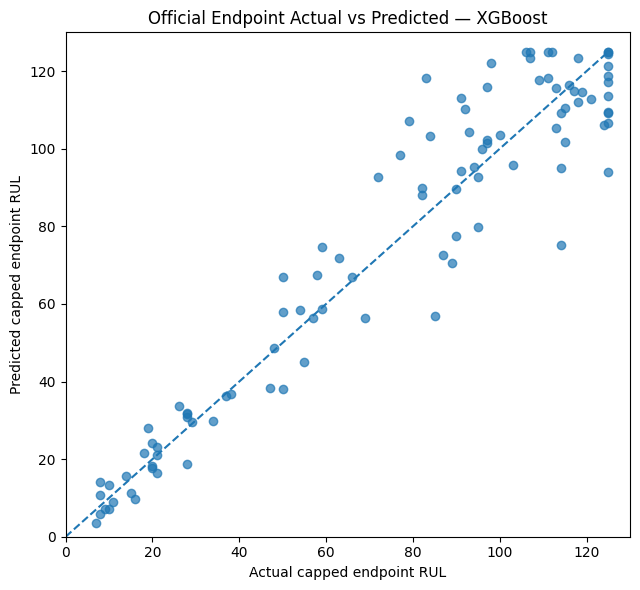

Saved: reports/final_summary/official_test_actual_vs_predicted_XGBoost_fd001.png


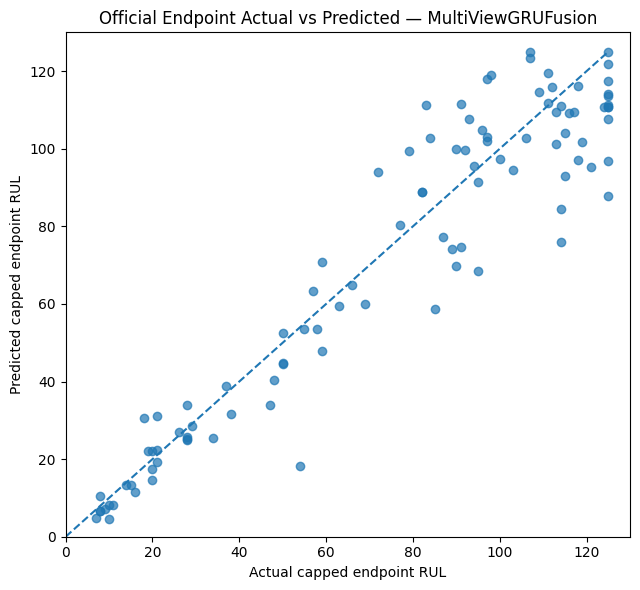

Saved: reports/final_summary/official_test_actual_vs_predicted_MultiViewGRUFusion_fd001.png


In [12]:
# Figures 5–6 — endpoint actual-versus-predicted plots for the best test model and the fusion model.
for model in ['XGBoost', 'MultiViewGRUFusion']:
    prediction_col = f'{model}_prediction'
    output_path = FINAL_SUMMARY_DIR / f'official_test_actual_vs_predicted_{model}_fd001.png'
    y = test_predictions_df['RUL_capped'].to_numpy(dtype=float)
    pred = test_predictions_df[prediction_col].to_numpy(dtype=float)

    plt.figure(figsize=(6.5, 6.0))
    plt.scatter(y, pred, alpha=0.7)
    plt.plot([0, 125], [0, 125], linestyle='--')
    plt.xlim(0, 130)
    plt.ylim(0, 130)
    plt.xlabel('Actual capped endpoint RUL')
    plt.ylabel('Predicted capped endpoint RUL')
    plt.title(f'Official Endpoint Actual vs Predicted — {model}')
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved:', output_path.relative_to(PROJECT_ROOT))


## Section 9 — Load and validate model-behaviour evidence

These artefacts explain model behaviour but do not replace the predictive evidence hierarchy. SHAP and feature importance describe the trained XGBoost model; they do not establish physical causality. View masking is an inference-time sensitivity test, not the performance of separately trained single-view models.


In [13]:
feature_importance_df = pd.read_csv(SOURCE_PATHS['feature_importance'])
shap_ranking_df = pd.read_csv(SOURCE_PATHS['shap_ranking'])
view_masking_df = pd.read_csv(SOURCE_PATHS['view_masking'])
local_cases_df = pd.read_csv(SOURCE_PATHS['local_cases'])
robustness_df = pd.read_csv(SOURCE_PATHS['robustness'])
rul_range_df = pd.read_csv(SOURCE_PATHS['rul_range'])
bias_df = pd.read_csv(SOURCE_PATHS['bias'])
noise_stability_df = pd.read_csv(SOURCE_PATHS['noise_stability'])
uncertainty_df = pd.read_csv(SOURCE_PATHS['uncertainty'])

require_columns(feature_importance_df, {'feature', 'importance'}, 'feature importance')
require_columns(shap_ranking_df, {'feature', 'mean_abs_shap'}, 'SHAP ranking')
require_columns(view_masking_df, {'condition', 'description', 'rmse', 'mae', 'r2'}, 'view masking')
require_columns(local_cases_df, {'case_type', 'unit_number', 'RUL_capped', 'prediction', 'error', 'abs_error'}, 'local cases')
require_columns(robustness_df, {'condition', 'perturbation_type', 'rmse', 'mae', 'r2', 'rmse_increase_pct'}, 'robustness')
require_columns(rul_range_df, {'rul_range', 'sample_count', 'rmse', 'mae', 'r2'}, 'RUL range')
require_columns(bias_df, {'mean_error', 'under_prediction_rate', 'within_20_cycles_rate'}, 'bias')
require_columns(noise_stability_df, {'perturbation_type', 'noise_std', 'rmse_mean', 'rmse_std'}, 'noise stability')
require_columns(uncertainty_df, {'n_runs', 'mean_prediction_std', 'median_prediction_std', 'uncertainty_abs_error_correlation'}, 'uncertainty')

assert set(view_masking_df['condition']) == {
    'both_views_available', 'sensor_sequence_masked', 'derived_view_masked'
}
assert set(rul_range_df['rul_range']) == {
    'near_failure_0_30', 'mid_degradation_31_80', 'early_or_capped_81_125'
}

print('Explainability and trustworthiness artefacts loaded and validated.')


Explainability and trustworthiness artefacts loaded and validated.


## Section 10 — Table F9: Explainability findings


In [14]:
def row_for_condition(df, condition):
    rows = df.loc[df['condition'].eq(condition)]
    if len(rows) != 1:
        raise AssertionError(f'Expected one row for condition {condition}, found {len(rows)}')
    return rows.iloc[0]


top_importance = feature_importance_df.sort_values('importance', ascending=False).head(5)
top_shap = shap_ranking_df.sort_values('mean_abs_shap', ascending=False).head(5)

both_views = row_for_condition(view_masking_df, 'both_views_available')
seq_masked = row_for_condition(view_masking_df, 'sensor_sequence_masked')
derived_masked = row_for_condition(view_masking_df, 'derived_view_masked')

explainability_rows = [
    {
        'check': 'XGBoost native feature importance',
        'quantitative_result': '; '.join(
            f"{r.feature}={r.importance:.4f}" for r in top_importance.itertuples()
        ),
        'finding': 'Rolling degradation summaries dominate the tree-model importance ranking.',
        'qualification': 'Native importance is model-specific and can be affected by correlated predictors; it is not physical causality.',
        'evidence_source': str(SOURCE_PATHS['feature_importance'].relative_to(PROJECT_ROOT)),
    },
    {
        'check': 'SHAP global ranking',
        'quantitative_result': '; '.join(
            f"{r.feature}={r.mean_abs_shap:.4f}" for r in top_shap.itertuples()
        ),
        'finding': 'The SHAP ranking identifies rolling sensor summaries and cycle_index among the strongest XGBoost contributors.',
        'qualification': 'SHAP explains the fitted XGBoost model on the evaluated data; it does not establish sensor-level causality.',
        'evidence_source': str(SOURCE_PATHS['shap_ranking'].relative_to(PROJECT_ROOT)),
    },
    {
        'check': 'Sensor-sequence view masked',
        'quantitative_result': (
            f"RMSE {seq_masked['rmse']:.4f} versus {both_views['rmse']:.4f} with both views; "
            f"delta {seq_masked['rmse'] - both_views['rmse']:.4f}"
        ),
        'finding': 'The trained fusion model retains substantial performance when the raw sequence branch is mean-value replaced after standardisation.',
        'qualification': 'Inference-time sensitivity test; not a separately trained derived-only model.',
        'evidence_source': str(SOURCE_PATHS['view_masking'].relative_to(PROJECT_ROOT)),
    },
    {
        'check': 'Derived view masked',
        'quantitative_result': (
            f"RMSE {derived_masked['rmse']:.4f} versus {both_views['rmse']:.4f} with both views; "
            f"delta {derived_masked['rmse'] - both_views['rmse']:.4f}"
        ),
        'finding': 'Performance collapses when the derived branch is masked, showing that the trained fusion model depends strongly on the engineered degradation representation.',
        'qualification': 'Inference-time masking does not measure the performance of the independently trained GRU baseline.',
        'evidence_source': str(SOURCE_PATHS['view_masking'].relative_to(PROJECT_ROOT)),
    },
    {
        'check': 'Local prediction cases',
        'quantitative_result': (
            f"{len(local_cases_df)} documented cases; case types: "
            + ', '.join(sorted(local_cases_df['case_type'].astype(str).unique()))
        ),
        'finding': 'Representative accurate, under-predicted and over-predicted cases provide case-level context for aggregate metrics.',
        'qualification': 'Illustrative examples are not a substitute for population-level evaluation.',
        'evidence_source': str(SOURCE_PATHS['local_cases'].relative_to(PROJECT_ROOT)),
    },
]

final_explainability_df = pd.DataFrame(explainability_rows)
explainability_path = FINAL_SUMMARY_DIR / 'final_explainability_table_fd001.csv'
final_explainability_df.to_csv(explainability_path, index=False)
display(final_explainability_df)


,check,quantitative_result,finding,qualification,evidence_source
0,XGBoost native feature importance,sensor_measurement_4_rmean=0.2758; sensor_measurement_11_rmean=0.2137; sensor_measurement_15_rmean=0.1791; sensor_measurement_2_rmean=0.0475; sensor_measurement_17_rmean=0.0426,Rolling degradation summaries dominate the tree-model importance ranking.,Native importance is model-specific and can be affected by correlated predictors; it is not physical causality.,reports/explainability/xgboost_feature_importance_fd001.csv
1,SHAP global ranking,sensor_measurement_4_rmean=6.6514; sensor_measurement_11_rmean=5.5294; cycle_index=5.3521; sensor_measurement_15_rmean=3.8792; sensor_measurement_11_delta=3.0260,The SHAP ranking identifies rolling sensor summaries and cycle_index among the strongest XGBoost contributors.,SHAP explains the fitted XGBoost model on the evaluated data; it does not establish sensor-level causality.,reports/explainability/xgboost_shap_feature_ranking_fd001.csv
2,Sensor-sequence view masked,RMSE 15.5505 versus 12.0657 with both views; delta 3.4848,The trained fusion model retains substantial performance when the raw sequence branch is mean-value replaced after standardisation.,Inference-time sensitivity test; not a separately trained derived-only model.,reports/explainability/multiview_view_masking_explainability_fd001.csv
3,Derived view masked,RMSE 42.5692 versus 12.0657 with both views; delta 30.5035,"Performance collapses when the derived branch is masked, showing that the trained fusion model depends strongly on the engineered degradation representation.",Inference-time masking does not measure the performance of the independently trained GRU baseline.,reports/explainability/multiview_view_masking_explainability_fd001.csv
4,Local prediction cases,"4 documented cases; case types: good_midrange_prediction, good_prediction, largest_over_prediction, largest_under_prediction","Representative accurate, under-predicted and over-predicted cases provide case-level context for aggregate metrics.",Illustrative examples are not a substitute for population-level evaluation.,reports/explainability/local_prediction_cases_multiview_fd001.csv


## Section 11 — Table F10: Trustworthiness findings


In [15]:
def robustness_condition(name):
    rows = robustness_df.loc[robustness_df['condition'].eq(name)]
    if len(rows) != 1:
        raise AssertionError(f'Expected one robustness row for {name}, found {len(rows)}')
    return rows.iloc[0]


def range_condition(name):
    rows = rul_range_df.loc[rul_range_df['rul_range'].eq(name)]
    if len(rows) != 1:
        raise AssertionError(f'Expected one RUL-range row for {name}, found {len(rows)}')
    return rows.iloc[0]


sensor_noise = robustness_condition('sensor_sequence_noise_0.2')
derived_noise = robustness_condition('derived_feature_noise_0.2')
combined_noise = robustness_condition('combined_noise_0.2')
sensor_mask = robustness_condition('sensor_sequence_random_mask_0.3')
derived_mask = robustness_condition('derived_feature_random_mask_0.3')
combined_mask = robustness_condition('combined_random_mask_0.3')
missing_derived = robustness_condition('derived_view_masked')

near_failure = range_condition('near_failure_0_30')
mid_degradation = range_condition('mid_degradation_31_80')
early_capped = range_condition('early_or_capped_81_125')

bias_row = bias_df.iloc[0]
uncertainty_row = uncertainty_df.iloc[0]
noise_std_min = float(noise_stability_df['rmse_std'].min())
noise_std_max = float(noise_stability_df['rmse_std'].max())

trustworthiness_rows = [
    {
        'check': 'Gaussian noise on raw sequence view',
        'quantitative_result': f"std=0.20 in standardised space; RMSE {sensor_noise['rmse']:.4f}; increase {sensor_noise['rmse_increase_pct']:.2f}%",
        'finding': 'The fusion model is comparatively stable to moderate perturbation of the raw sequence view.',
        'qualification': 'Synthetic Gaussian noise in standardised space is a controlled sensitivity test, not a complete field-noise model.',
        'evidence_source': str(SOURCE_PATHS['robustness'].relative_to(PROJECT_ROOT)),
    },
    {
        'check': 'Gaussian noise on derived view',
        'quantitative_result': f"std=0.20 in standardised space; RMSE {derived_noise['rmse']:.4f}; increase {derived_noise['rmse_increase_pct']:.2f}%",
        'finding': 'The model is more sensitive to derived-feature perturbation than to raw-sequence perturbation.',
        'qualification': 'The result applies to the frozen seed-42 fusion model and selected perturbation magnitude.',
        'evidence_source': str(SOURCE_PATHS['robustness'].relative_to(PROJECT_ROOT)),
    },
    {
        'check': 'Combined Gaussian noise',
        'quantitative_result': f"std=0.20; RMSE {combined_noise['rmse']:.4f}; increase {combined_noise['rmse_increase_pct']:.2f}%",
        'finding': 'Simultaneous perturbation of both views causes a larger but still controlled degradation than raw-view noise alone.',
        'qualification': 'Synthetic standardised perturbation only.',
        'evidence_source': str(SOURCE_PATHS['robustness'].relative_to(PROJECT_ROOT)),
    },
    {
        'check': 'Random masking at 30%',
        'quantitative_result': (
            f"sequence RMSE {sensor_mask['rmse']:.4f}; derived RMSE {derived_mask['rmse']:.4f}; "
            f"combined RMSE {combined_mask['rmse']:.4f}"
        ),
        'finding': 'Random masking confirms greater sensitivity to the derived view and the strongest degradation when both views are affected.',
        'qualification': 'Masked values are replaced by zero after standardisation, approximately the training mean.',
        'evidence_source': str(SOURCE_PATHS['robustness'].relative_to(PROJECT_ROOT)),
    },
    {
        'check': 'Complete derived-view masking',
        'quantitative_result': f"RMSE {missing_derived['rmse']:.4f}; R² {missing_derived['r2']:.4f}",
        'finding': 'The frozen fusion model is not robust to complete loss of the derived degradation branch.',
        'qualification': 'Inference-time missing-view sensitivity; not a separately trained raw-sequence model.',
        'evidence_source': str(SOURCE_PATHS['robustness'].relative_to(PROJECT_ROOT)),
    },
    {
        'check': 'RUL-region error',
        'quantitative_result': (
            f"near failure RMSE {near_failure['rmse']:.4f}; mid degradation {mid_degradation['rmse']:.4f}; "
            f"early/capped {early_capped['rmse']:.4f}"
        ),
        'finding': 'Prediction is most accurate near failure and less accurate in the early or capped lifecycle region.',
        'qualification': 'Region sizes differ and the capped target compresses early-life labels.',
        'evidence_source': str(SOURCE_PATHS['rul_range'].relative_to(PROJECT_ROOT)),
    },
    {
        'check': 'Prediction bias',
        'quantitative_result': (
            f"mean error {bias_row['mean_error']:.4f}; under-prediction rate {bias_row['under_prediction_rate']:.4f}; "
            f"within 20 cycles {bias_row['within_20_cycles_rate']:.4f}"
        ),
        'finding': 'The historical seed-42 fusion model has a modest aggregate under-prediction tendency.',
        'qualification': 'Mean error is prediction minus actual; business consequences of early and late predictions were not cost-weighted.',
        'evidence_source': str(SOURCE_PATHS['bias'].relative_to(PROJECT_ROOT)),
    },
    {
        'check': 'Repeated perturbation stability',
        'quantitative_result': f"RMSE standard deviation range {noise_std_min:.4f}–{noise_std_max:.4f} across repeated noise runs",
        'finding': 'The selected stochastic perturbation results are stable across repeated random draws.',
        'qualification': 'Five repeats at one noise magnitude; descriptive rather than inferential evidence.',
        'evidence_source': str(SOURCE_PATHS['noise_stability'].relative_to(PROJECT_ROOT)),
    },
    {
        'check': 'Exploratory MC Dropout uncertainty',
        'quantitative_result': (
            f"{int(uncertainty_row['n_runs'])} passes; mean std {uncertainty_row['mean_prediction_std']:.4f}; "
            f"median std {uncertainty_row['median_prediction_std']:.4f}; uncertainty-error correlation "
            f"{uncertainty_row['uncertainty_abs_error_correlation']:.4f}"
        ),
        'finding': 'Predictive dispersion has moderate alignment with absolute error and may help identify difficult cases.',
        'qualification': 'MC Dropout dispersion is exploratory and uncalibrated; it is not a confidence interval or reliability guarantee.',
        'evidence_source': str(SOURCE_PATHS['uncertainty'].relative_to(PROJECT_ROOT)),
    },
]

final_trustworthiness_df = pd.DataFrame(trustworthiness_rows)
trustworthiness_path = FINAL_SUMMARY_DIR / 'final_trustworthiness_table_fd001.csv'
final_trustworthiness_df.to_csv(trustworthiness_path, index=False)
display(final_trustworthiness_df)


,check,quantitative_result,finding,qualification,evidence_source
0,Gaussian noise on raw sequence view,std=0.20 in standardised space; RMSE 12.1026; increase 0.31%,The fusion model is comparatively stable to moderate perturbation of the raw sequence view.,"Synthetic Gaussian noise in standardised space is a controlled sensitivity test, not a complete field-noise model.",reports/robustness/robustness_summary_multiview_fd001.csv
1,Gaussian noise on derived view,std=0.20 in standardised space; RMSE 12.5102; increase 3.68%,The model is more sensitive to derived-feature perturbation than to raw-sequence perturbation.,The result applies to the frozen seed-42 fusion model and selected perturbation magnitude.,reports/robustness/robustness_summary_multiview_fd001.csv
2,Combined Gaussian noise,std=0.20; RMSE 12.5906; increase 4.35%,Simultaneous perturbation of both views causes a larger but still controlled degradation than raw-view noise alone.,Synthetic standardised perturbation only.,reports/robustness/robustness_summary_multiview_fd001.csv
3,Random masking at 30%,sequence RMSE 12.5428; derived RMSE 17.7557; combined RMSE 19.0455,Random masking confirms greater sensitivity to the derived view and the strongest degradation when both views are affected.,"Masked values are replaced by zero after standardisation, approximately the training mean.",reports/robustness/robustness_summary_multiview_fd001.csv
4,Complete derived-view masking,RMSE 42.5692; R² -0.0354,The frozen fusion model is not robust to complete loss of the derived degradation branch.,Inference-time missing-view sensitivity; not a separately trained raw-sequence model.,reports/robustness/robustness_summary_multiview_fd001.csv
5,RUL-region error,near failure RMSE 4.4301; mid degradation 12.0633; early/capped 13.5262,Prediction is most accurate near failure and less accurate in the early or capped lifecycle region.,Region sizes differ and the capped target compresses early-life labels.,reports/robustness/rul_range_error_analysis_multiview_fd001.csv
6,Prediction bias,mean error -2.2779; under-prediction rate 0.5648; within 20 cycles 0.9046,The historical seed-42 fusion model has a modest aggregate under-prediction tendency.,Mean error is prediction minus actual; business consequences of early and late predictions were not cost-weighted.,reports/robustness/prediction_bias_summary_multiview_fd001.csv
7,Repeated perturbation stability,RMSE standard deviation range 0.0092–0.0339 across repeated noise runs,The selected stochastic perturbation results are stable across repeated random draws.,Five repeats at one noise magnitude; descriptive rather than inferential evidence.,reports/robustness/repeated_noise_stability_summary_multiview_fd001.csv
8,Exploratory MC Dropout uncertainty,30 passes; mean std 7.4738; median std 7.7246; uncertainty-error correlation 0.4875,Predictive dispersion has moderate alignment with absolute error and may help identify difficult cases.,MC Dropout dispersion is exploratory and uncalibrated; it is not a confidence interval or reliability guarantee.,reports/robustness/mc_dropout_uncertainty_summary_multiview_fd001.csv


## Section 12 — Table F11 and E54: Research-question evidence

The answers below are deliberately phrased as evidence-based conclusions rather than as universal claims.


In [16]:
validation_winner = repeated_summary_df.sort_values('mean_rmse').iloc[0]
test_winner = test_metrics_df.sort_values('rmse').iloc[0]
fusion_validation = repeated_summary_df.loc[repeated_summary_df['model'].eq('MultiViewGRUFusion')].iloc[0]
derived_validation = repeated_summary_df.loc[repeated_summary_df['model'].eq('DerivedOnlyMLP')].iloc[0]

split_winner_text = '; '.join(
    f"seed {int(r.split_seed)}: {r.winning_model} ({r.winning_rmse:.4f})"
    for r in split_winners.itertuples()
)

ablation_text = '; '.join(
    f"{r.model}: +{r.rmse_delta_pct:.2f}% RMSE"
    for r in ablation_df.sort_values('model').itertuples()
)

top_shap_names = ', '.join(top_shap['feature'].head(5).astype(str).tolist())

rq_rows = [
    {
        'research_question': 'RQ1',
        'question': 'How do raw sensor sequences, engineered degradation features and their fusion compare for capped RUL prediction on FD001?',
        'primary_evidence': 'NB10 repeated validation; NB11 official endpoint evaluation',
        'key_result': (
            f"{validation_winner['model']} had the lowest mean validation RMSE ({validation_winner['mean_rmse']:.4f}); "
            f"{test_winner['model']} had the lowest official endpoint RMSE ({test_winner['rmse']:.4f}). "
            f"Fusion mean validation RMSE was {fusion_validation['mean_rmse']:.4f} and official-test RMSE was "
            f"{test_metrics_df.loc[test_metrics_df['model'].eq('MultiViewGRUFusion'), 'rmse'].iloc[0]:.4f}."
        ),
        'answer': 'Engineered degradation features provide a strong and consistent representation. Fusion is competitive on some cohorts but is not consistently superior to the strongest single-view or classical model.',
        'qualification': 'Outcome C is primary. The conclusion applies to one frozen fusion architecture on FD001 under capped-RUL evaluation.',
        'evidence_ids': 'E05, E06, E07, E07a, E10, E11',
    },
    {
        'research_question': 'RQ2',
        'question': 'What predictive contribution does each view provide, and which derived features most strongly influence predictions?',
        'primary_evidence': 'NB07 feature importance, SHAP and view masking; NB10 cycle_index ablation',
        'key_result': (
            f"Top SHAP features include {top_shap_names}. View masking RMSE was {seq_masked['rmse']:.4f} with the "
            f"sensor sequence masked and {derived_masked['rmse']:.4f} with the derived view masked. "
            f"Removing cycle_index changed RMSE by: {ablation_text}."
        ),
        'answer': 'The derived degradation view carries much of the predictive information. The raw sequence view can add complementary signal, but its incremental benefit is not stable across splits.',
        'qualification': 'SHAP and feature importance describe model behaviour, not physical causality. View masking is an inference-time sensitivity test.',
        'evidence_ids': 'E09, E13–E24',
    },
    {
        'research_question': 'RQ3',
        'question': 'How does the fusion model behave under controlled noise, masking, missing-view conditions and different RUL regions?',
        'primary_evidence': 'NB08 robustness, RUL-region, bias, stability and MC Dropout analyses',
        'key_result': (
            f"At standardised noise std 0.20, sensor/derived/combined RMSE values were "
            f"{sensor_noise['rmse']:.4f}/{derived_noise['rmse']:.4f}/{combined_noise['rmse']:.4f}. "
            f"Near-failure RMSE was {near_failure['rmse']:.4f}, compared with {early_capped['rmse']:.4f} in the early/capped region. "
            f"MC Dropout uncertainty-error correlation was {uncertainty_row['uncertainty_abs_error_correlation']:.4f}."
        ),
        'answer': 'The fusion model is relatively stable to moderate synthetic noise but is more sensitive to derived-feature corruption and complete derived-view loss. Accuracy is strongest near failure. Uncertainty dispersion provides only an exploratory difficulty signal.',
        'qualification': 'Perturbations are synthetic; MC Dropout is uncalibrated; evidence is based on the frozen historical seed-42 fusion model.',
        'evidence_ids': 'E25–E34',
    },
    {
        'research_question': 'RQ4',
        'question': 'How stable are the main findings across engine-level validation splits and on independent FD001 test engines?',
        'primary_evidence': 'NB10 split-level results and NB11 one-time official endpoint evaluation',
        'key_result': (
            f"Split winners were {split_winner_text}. The official endpoint winner was {test_winner['model']} "
            f"with RMSE {test_winner['rmse']:.4f}."
        ),
        'answer': 'Model ranking is sensitive to engine cohort and evaluation population. Repeated grouped validation and an untouched test evaluation provide a more reliable conclusion than a single split.',
        'qualification': 'Only three split configurations were evaluated, so variability is descriptive rather than a formal statistical comparison. Validation-window and test-endpoint RMSE values are not directly interchangeable.',
        'evidence_ids': 'E05–E08, E10–E12',
    },
]

rq_evidence_df = pd.DataFrame(rq_rows)
rq_path = FINAL_SUMMARY_DIR / 'research_question_evidence_fd001.csv'
rq_evidence_df.to_csv(rq_path, index=False)
display(rq_evidence_df)


,research_question,question,primary_evidence,key_result,answer,qualification,evidence_ids
0,RQ1,"How do raw sensor sequences, engineered degradation features and their fusion compare for capped RUL prediction on FD001?",NB10 repeated validation; NB11 official endpoint evaluation,DerivedOnlyMLP had the lowest mean validation RMSE (14.2308); XGBoost had the lowest official endpoint RMSE (12.2459). Fusion mean validation RMSE was 14.2787 and official-test...,Engineered degradation features provide a strong and consistent representation. Fusion is competitive on some cohorts but is not consistently superior to the strongest single-v...,Outcome C is primary. The conclusion applies to one frozen fusion architecture on FD001 under capped-RUL evaluation.,"E05, E06, E07, E07a, E10, E11"
1,RQ2,"What predictive contribution does each view provide, and which derived features most strongly influence predictions?","NB07 feature importance, SHAP and view masking; NB10 cycle_index ablation","Top SHAP features include sensor_measurement_4_rmean, sensor_measurement_11_rmean, cycle_index, sensor_measurement_15_rmean, sensor_measurement_11_delta. View masking RMSE was ...","The derived degradation view carries much of the predictive information. The raw sequence view can add complementary signal, but its incremental benefit is not stable across sp...","SHAP and feature importance describe model behaviour, not physical causality. View masking is an inference-time sensitivity test.","E09, E13–E24"
2,RQ3,"How does the fusion model behave under controlled noise, masking, missing-view conditions and different RUL regions?","NB08 robustness, RUL-region, bias, stability and MC Dropout analyses","At standardised noise std 0.20, sensor/derived/combined RMSE values were 12.1026/12.5102/12.5906. Near-failure RMSE was 4.4301, compared with 13.5262 in the early/capped region...",The fusion model is relatively stable to moderate synthetic noise but is more sensitive to derived-feature corruption and complete derived-view loss. Accuracy is strongest near...,Perturbations are synthetic; MC Dropout is uncalibrated; evidence is based on the frozen historical seed-42 fusion model.,E25–E34
3,RQ4,How stable are the main findings across engine-level validation splits and on independent FD001 test engines?,NB10 split-level results and NB11 one-time official endpoint evaluation,Split winners were seed 21: DerivedOnlyMLP (14.0158); seed 42: XGBoost (12.5341); seed 84: GRU (14.8684). The official endpoint winner was XGBoost with RMSE 12.2459.,Model ranking is sensitive to engine cohort and evaluation population. Repeated grouped validation and an untouched test evaluation provide a more reliable conclusion than a si...,"Only three split configurations were evaluated, so variability is descriptive rather than a formal statistical comparison. Validation-window and test-endpoint RMSE values are n...","E05–E08, E10–E12"


## Section 13 — Table F12 and E55: Limitations, treatment and future work


In [17]:
limitations_rows = [
    {
        'limitation_id': 'L01',
        'limitation': 'The experimental scope is limited to C-MAPSS FD001.',
        'impact_on_interpretation': 'Findings are established for one operating condition and one fault mode and should not be generalised to all industrial assets.',
        'current_treatment': 'The report explicitly scopes all conclusions to FD001.',
        'future_work': 'Evaluate FD002–FD004 and external industrial datasets with multiple regimes and fault mechanisms.',
    },
    {
        'limitation_id': 'L02',
        'limitation': 'The work is benchmark-driven multi-view learning rather than native multimodality.',
        'impact_on_interpretation': 'Both views are derived from the same numerical sensor stream; no image, audio, text or independently aligned modality is used.',
        'current_treatment': 'The dissertation uses the term multi-view and states the multimodality boundary clearly.',
        'future_work': 'Fuse temporally aligned sensor data with inspection images, maintenance text or acoustic/vibration modalities.',
    },
    {
        'limitation_id': 'L03',
        'limitation': 'Repeated validation uses three engine-level split configurations.',
        'impact_on_interpretation': 'Mean and standard deviation describe cohort sensitivity but do not establish formal statistical superiority.',
        'current_treatment': 'All variability statements are described as descriptive evidence.',
        'future_work': 'Use more repeated grouped splits, nested validation or bootstrap confidence intervals at engine level.',
    },
    {
        'limitation_id': 'L04',
        'limitation': 'Validation and official-test evaluation units differ.',
        'impact_on_interpretation': 'Validation uses all eligible windows, whereas official test evaluation uses one endpoint per engine.',
        'current_treatment': 'Rankings are compared descriptively; absolute RMSE values are not presented as a direct generalisation gap.',
        'future_work': 'Add endpoint-only validation analysis or matched evaluation units in future experiments.',
    },
    {
        'limitation_id': 'L05',
        'limitation': 'The capped-RUL formulation compresses early-life targets above 125 cycles.',
        'impact_on_interpretation': 'Performance emphasises degradation and later-life prediction rather than exact early-life RUL.',
        'current_treatment': 'All reported results state the 125-cycle cap and the official-test capping rule.',
        'future_work': 'Compare capped and uncapped targets and assess sensitivity to alternative cap values.',
    },
    {
        'limitation_id': 'L06',
        'limitation': 'Only one frozen fusion architecture is evaluated.',
        'impact_on_interpretation': 'The negative fusion result does not prove that all fusion approaches are ineffective.',
        'current_treatment': 'The conclusion is limited to the implemented GRU–MLP concatenation architecture.',
        'future_work': 'Evaluate gated, attention-based or uncertainty-aware fusion under a larger controlled study.',
    },
    {
        'limitation_id': 'L07',
        'limitation': 'The models depend materially on cycle_index.',
        'impact_on_interpretation': 'Explicit lifecycle position contributes useful signal but may act as a shortcut when operating histories differ from FD001.',
        'current_treatment': 'A dedicated ablation quantifies the dependence and the report avoids labelling it as leakage.',
        'future_work': 'Test models without explicit cycle position and under shifted lifecycle distributions.',
    },
    {
        'limitation_id': 'L08',
        'limitation': 'Feature-level attribution is strongest for XGBoost; neural explanation is mainly view-level.',
        'impact_on_interpretation': 'The fusion network is not explained at individual timestep and sensor attribution level.',
        'current_treatment': 'View masking and local cases provide bounded neural-model interpretation.',
        'future_work': 'Apply Integrated Gradients or sequence-aware attribution with stability checks.',
    },
    {
        'limitation_id': 'L09',
        'limitation': 'MC Dropout uncertainty is uncalibrated.',
        'impact_on_interpretation': 'Prediction standard deviation cannot be interpreted as a calibrated confidence interval.',
        'current_treatment': 'Uncertainty is reported only as exploratory predictive dispersion.',
        'future_work': 'Evaluate conformal prediction, calibration curves and coverage-aware intervals.',
    },
    {
        'limitation_id': 'L10',
        'limitation': 'The NASA asymmetric scoring function is not part of the principal evaluation.',
        'impact_on_interpretation': 'The study does not explicitly weight late predictions more strongly than early predictions.',
        'current_treatment': 'RMSE, MAE, R² and signed error are reported transparently.',
        'future_work': 'Add asymmetric maintenance-cost and NASA-score analysis under matched benchmark definitions.',
    },
    {
        'limitation_id': 'L11',
        'limitation': 'The work is a benchmark prototype and not a production deployment.',
        'impact_on_interpretation': 'Operational latency, concept drift, sensor quality, integration and maintenance-cost decisions are not validated in a live system.',
        'current_treatment': 'The report positions the work as applied benchmark research relevant to predictive-maintenance decision support.',
        'future_work': 'Conduct deployment-oriented validation with monitoring, drift detection, business-cost thresholds and human-in-the-loop review.',
    },
]

limitations_df = pd.DataFrame(limitations_rows)
limitations_path = FINAL_SUMMARY_DIR / 'final_limitations_fd001.csv'
limitations_df.to_csv(limitations_path, index=False)
display(limitations_df)


,limitation_id,limitation,impact_on_interpretation,current_treatment,future_work
0,L01,The experimental scope is limited to C-MAPSS FD001.,Findings are established for one operating condition and one fault mode and should not be generalised to all industrial assets.,The report explicitly scopes all conclusions to FD001.,Evaluate FD002–FD004 and external industrial datasets with multiple regimes and fault mechanisms.
1,L02,The work is benchmark-driven multi-view learning rather than native multimodality.,"Both views are derived from the same numerical sensor stream; no image, audio, text or independently aligned modality is used.",The dissertation uses the term multi-view and states the multimodality boundary clearly.,"Fuse temporally aligned sensor data with inspection images, maintenance text or acoustic/vibration modalities."
2,L03,Repeated validation uses three engine-level split configurations.,Mean and standard deviation describe cohort sensitivity but do not establish formal statistical superiority.,All variability statements are described as descriptive evidence.,"Use more repeated grouped splits, nested validation or bootstrap confidence intervals at engine level."
3,L04,Validation and official-test evaluation units differ.,"Validation uses all eligible windows, whereas official test evaluation uses one endpoint per engine.",Rankings are compared descriptively; absolute RMSE values are not presented as a direct generalisation gap.,Add endpoint-only validation analysis or matched evaluation units in future experiments.
4,L05,The capped-RUL formulation compresses early-life targets above 125 cycles.,Performance emphasises degradation and later-life prediction rather than exact early-life RUL.,All reported results state the 125-cycle cap and the official-test capping rule.,Compare capped and uncapped targets and assess sensitivity to alternative cap values.
5,L06,Only one frozen fusion architecture is evaluated.,The negative fusion result does not prove that all fusion approaches are ineffective.,The conclusion is limited to the implemented GRU–MLP concatenation architecture.,"Evaluate gated, attention-based or uncertainty-aware fusion under a larger controlled study."
6,L07,The models depend materially on cycle_index.,Explicit lifecycle position contributes useful signal but may act as a shortcut when operating histories differ from FD001.,A dedicated ablation quantifies the dependence and the report avoids labelling it as leakage.,Test models without explicit cycle position and under shifted lifecycle distributions.
7,L08,Feature-level attribution is strongest for XGBoost; neural explanation is mainly view-level.,The fusion network is not explained at individual timestep and sensor attribution level.,View masking and local cases provide bounded neural-model interpretation.,Apply Integrated Gradients or sequence-aware attribution with stability checks.
8,L09,MC Dropout uncertainty is uncalibrated.,Prediction standard deviation cannot be interpreted as a calibrated confidence interval.,Uncertainty is reported only as exploratory predictive dispersion.,"Evaluate conformal prediction, calibration curves and coverage-aware intervals."
9,L10,The NASA asymmetric scoring function is not part of the principal evaluation.,The study does not explicitly weight late predictions more strongly than early predictions.,"RMSE, MAE, R² and signed error are reported transparently.",Add asymmetric maintenance-cost and NASA-score analysis under matched benchmark definitions.


## Section 14 — E56: Final claims and qualifications

This table distinguishes defensible dissertation claims from wording that would overstate the evidence.


In [18]:
claims_rows = [
    {
        'claim_id': 'C01',
        'defensible_claim': 'A leakage-aware engine-grouped pipeline was implemented for capped RUL regression on C-MAPSS FD001.',
        'evidence': 'NB03, NB10 protocol assertions and NB11 frozen test protocol',
        'required_qualification': 'Scope is FD001 and the target is capped at 125 cycles.',
        'avoid_wording': 'The pipeline eliminates all possible leakage in any predictive-maintenance setting.',
    },
    {
        'claim_id': 'C02',
        'defensible_claim': 'DerivedOnlyMLP produced the lowest mean RMSE across the three final-protocol validation splits.',
        'evidence': 'E05 and E06',
        'required_qualification': 'Three split configurations provide descriptive stability evidence, not formal statistical superiority.',
        'avoid_wording': 'DerivedOnlyMLP is universally the best FD001 model.',
    },
    {
        'claim_id': 'C03',
        'defensible_claim': 'XGBoost achieved the strongest one-time official FD001 endpoint result under the capped-RUL formulation.',
        'evidence': 'E10 and E11',
        'required_qualification': 'One endpoint per engine; labels capped at 125; predictions clipped to [0, 125].',
        'avoid_wording': 'XGBoost is state of the art on the standard uncapped NASA benchmark.',
    },
    {
        'claim_id': 'C04',
        'defensible_claim': 'The implemented fusion model was competitive on some engine cohorts but did not consistently outperform the strongest single-view or classical alternative.',
        'evidence': 'E05–E07a and E10',
        'required_qualification': 'Conclusion applies to the frozen GRU–MLP concatenation architecture.',
        'avoid_wording': 'Multimodal fusion is ineffective for predictive maintenance.',
    },
    {
        'claim_id': 'C05',
        'defensible_claim': 'The engineered degradation view carries much of the predictive information in the current formulation.',
        'evidence': 'E09, E13–E22',
        'required_qualification': 'Based on model behaviour, ablation and masking; not a physical-causality claim.',
        'avoid_wording': 'Raw sensor sequences add no information.',
    },
    {
        'claim_id': 'C06',
        'defensible_claim': 'Removing cycle_index worsened RMSE for XGBoost, DerivedOnlyMLP and Fusion in the paired seed-42 ablation.',
        'evidence': 'E09',
        'required_qualification': 'cycle_index is available at prediction time; the result demonstrates dependence, not target leakage by itself.',
        'avoid_wording': 'cycle_index is leakage and therefore invalid.',
    },
    {
        'claim_id': 'C07',
        'defensible_claim': 'XGBoost importance and SHAP identify rolling degradation features and cycle_index as influential model inputs.',
        'evidence': 'E13–E20',
        'required_qualification': 'Attribution is model- and dataset-specific and does not establish sensor causality.',
        'avoid_wording': 'These variables physically cause engine degradation.',
    },
    {
        'claim_id': 'C08',
        'defensible_claim': 'The fusion model is more sensitive to derived-feature corruption and complete derived-view loss than to comparable raw-sequence perturbation.',
        'evidence': 'E21, E22, E25–E31',
        'required_qualification': 'Synthetic perturbations and inference-time masking on the historical seed-42 model.',
        'avoid_wording': 'The model is robust to all realistic sensor failures.',
    },
    {
        'claim_id': 'C09',
        'defensible_claim': 'MC Dropout dispersion shows moderate association with absolute prediction error.',
        'evidence': 'E32–E34',
        'required_qualification': 'Uncalibrated exploratory uncertainty signal only.',
        'avoid_wording': 'The model provides calibrated confidence intervals.',
    },
    {
        'claim_id': 'C10',
        'defensible_claim': 'The dissertation contributes a controlled multi-view, explainability and trustworthiness evaluation rather than a claim of universal predictive superiority.',
        'evidence': 'E01–E56',
        'required_qualification': 'Benchmark prototype on FD001; not a production or native multimodal deployment.',
        'avoid_wording': 'The work proves a production-ready multimodal solution for industrial assets.',
    },
]

claims_df = pd.DataFrame(claims_rows)
claims_path = FINAL_SUMMARY_DIR / 'final_claims_and_qualifications_fd001.csv'
claims_df.to_csv(claims_path, index=False)
display(claims_df)


,claim_id,defensible_claim,evidence,required_qualification,avoid_wording
0,C01,A leakage-aware engine-grouped pipeline was implemented for capped RUL regression on C-MAPSS FD001.,"NB03, NB10 protocol assertions and NB11 frozen test protocol",Scope is FD001 and the target is capped at 125 cycles.,The pipeline eliminates all possible leakage in any predictive-maintenance setting.
1,C02,DerivedOnlyMLP produced the lowest mean RMSE across the three final-protocol validation splits.,E05 and E06,"Three split configurations provide descriptive stability evidence, not formal statistical superiority.",DerivedOnlyMLP is universally the best FD001 model.
2,C03,XGBoost achieved the strongest one-time official FD001 endpoint result under the capped-RUL formulation.,E10 and E11,"One endpoint per engine; labels capped at 125; predictions clipped to [0, 125].",XGBoost is state of the art on the standard uncapped NASA benchmark.
3,C04,The implemented fusion model was competitive on some engine cohorts but did not consistently outperform the strongest single-view or classical alternative.,E05–E07a and E10,Conclusion applies to the frozen GRU–MLP concatenation architecture.,Multimodal fusion is ineffective for predictive maintenance.
4,C05,The engineered degradation view carries much of the predictive information in the current formulation.,"E09, E13–E22","Based on model behaviour, ablation and masking; not a physical-causality claim.",Raw sensor sequences add no information.
5,C06,"Removing cycle_index worsened RMSE for XGBoost, DerivedOnlyMLP and Fusion in the paired seed-42 ablation.",E09,"cycle_index is available at prediction time; the result demonstrates dependence, not target leakage by itself.",cycle_index is leakage and therefore invalid.
6,C07,XGBoost importance and SHAP identify rolling degradation features and cycle_index as influential model inputs.,E13–E20,Attribution is model- and dataset-specific and does not establish sensor causality.,These variables physically cause engine degradation.
7,C08,The fusion model is more sensitive to derived-feature corruption and complete derived-view loss than to comparable raw-sequence perturbation.,"E21, E22, E25–E31",Synthetic perturbations and inference-time masking on the historical seed-42 model.,The model is robust to all realistic sensor failures.
8,C09,MC Dropout dispersion shows moderate association with absolute prediction error.,E32–E34,Uncalibrated exploratory uncertainty signal only.,The model provides calibrated confidence intervals.
9,C10,"The dissertation contributes a controlled multi-view, explainability and trustworthiness evaluation rather than a claim of universal predictive superiority.",E01–E56,Benchmark prototype on FD001; not a production or native multimodal deployment.,The work proves a production-ready multimodal solution for industrial assets.


## Section 15 — Final report asset checklist

The final report should use only a limited number of figures in the main body. The checklist below distinguishes main-report recommendations from appendix or traceability material.


In [19]:
asset_rows = [
    # Tables generated by NB12
    ('F1', 'Table', 'Experimental protocol summary', protocol_path, 'Main report'),
    ('F2', 'Table', 'Historical seed-42 window-aligned reference', historical_path, 'Main report with one-split qualification'),
    ('F3', 'Table', 'Repeated-validation split results', f3_path, 'Main report'),
    ('F4', 'Table', 'Repeated-validation mean ± SD', f4_report_path, 'Main report'),
    ('F5', 'Table', 'Fusion comparison and win counts', f5_path, 'Main report or appendix depending on space'),
    ('F6', 'Table', 'cycle_index ablation', f6_path, 'Main report'),
    ('F7', 'Table', 'Per-engine performance summary', f7_path, 'Main report or appendix'),
    ('F8', 'Table', 'Official endpoint test results', f8_path, 'Main report'),
    ('F9', 'Table', 'Explainability findings', explainability_path, 'Main report'),
    ('F10', 'Table', 'Trustworthiness findings', trustworthiness_path, 'Main report'),
    ('F11', 'Table', 'Research-question evidence', rq_path, 'Discussion chapter'),
    ('F12', 'Table', 'Limitations and mitigations', limitations_path, 'Conclusion chapter'),
    ('E53', 'Table', 'Final validation-test model comparison', final_model_path, 'Main report'),
    ('E56', 'Table', 'Claims and qualifications', claims_path, 'Writing control / appendix'),

    # NB12 figures
    ('Fig-Final-1', 'Figure', 'Repeated-validation mean RMSE', fig_path_validation_mean, 'Main report'),
    ('Fig-Final-2', 'Figure', 'Split-level RMSE by engine cohort', fig_path_validation_split, 'Main report'),
    ('Fig-Final-3', 'Figure', 'Official endpoint RMSE comparison', fig_path_test_rmse, 'Main report'),
    ('Fig-Final-4', 'Figure', 'Validation-versus-test rank comparison', fig_path_rank, 'Discussion chapter'),
    ('Fig-Final-5', 'Figure', 'Official actual vs predicted — XGBoost', FINAL_SUMMARY_DIR / 'official_test_actual_vs_predicted_XGBoost_fd001.png', 'Main report'),
    ('Fig-Final-6', 'Figure', 'Official actual vs predicted — Fusion', FINAL_SUMMARY_DIR / 'official_test_actual_vs_predicted_MultiViewGRUFusion_fd001.png', 'Appendix or discussion'),

    # Existing figures recommended for the final report
    ('Fig-EDA', 'Figure', 'RUL distribution and cap context', PROJECT_ROOT / 'reports/figures/rul_capping_comparison_fd001.png', 'Main report'),
    ('Fig-SHAP', 'Figure', 'SHAP summary for XGBoost', PROJECT_ROOT / 'reports/figures/shap_summary_xgboost_fd001.png', 'Main report'),
    ('Fig-View', 'Figure', 'View-masking sensitivity', PROJECT_ROOT / 'reports/figures/multiview_view_masking_rmse_fd001.png', 'Main report'),
    ('Fig-Robust', 'Figure', 'Robustness comparison', PROJECT_ROOT / 'reports/figures/robustness_summary_rmse_multiview_fd001.png', 'Main report'),
    ('Fig-RUL-Region', 'Figure', 'RUL range-wise error', PROJECT_ROOT / 'reports/figures/rul_range_error_multiview_fd001.png', 'Main report or appendix'),
    ('Fig-Uncertainty', 'Figure', 'Uncertainty versus error', PROJECT_ROOT / 'reports/figures/uncertainty_vs_error_multiview_fd001.png', 'Appendix'),
]

asset_checklist_df = pd.DataFrame(
    asset_rows,
    columns=['asset_id', 'asset_type', 'description', 'absolute_path', 'recommended_placement']
)
asset_checklist_df['relative_path'] = asset_checklist_df['absolute_path'].apply(
    lambda p: str(Path(p).relative_to(PROJECT_ROOT))
)
asset_checklist_df['status'] = asset_checklist_df['absolute_path'].apply(
    lambda p: 'Ready' if Path(p).is_file() else 'Missing'
)
asset_checklist_df = asset_checklist_df[
    ['asset_id', 'asset_type', 'description', 'relative_path', 'recommended_placement', 'status']
]

asset_checklist_path = FINAL_SUMMARY_DIR / 'final_report_asset_checklist_fd001.csv'
asset_checklist_df.to_csv(asset_checklist_path, index=False)
display(asset_checklist_df)

missing_assets = asset_checklist_df.loc[asset_checklist_df['status'].eq('Missing')]
if len(missing_assets):
    print('\nWARNING: Some report assets are missing. Review before final report assembly:')
    display(missing_assets)
else:
    print('\nAll listed report assets are ready.')


,asset_id,asset_type,description,relative_path,recommended_placement,status
0,F1,Table,Experimental protocol summary,reports/final_summary/experimental_protocol_summary_fd001.csv,Main report,Ready
1,F2,Table,Historical seed-42 window-aligned reference,reports/final_summary/seed42_historical_reference_fd001.csv,Main report with one-split qualification,Ready
2,F3,Table,Repeated-validation split results,reports/final_summary/repeated_validation_split_report_fd001.csv,Main report,Ready
3,F4,Table,Repeated-validation mean ± SD,reports/final_summary/repeated_validation_report_table_fd001.csv,Main report,Ready
4,F5,Table,Fusion comparison and win counts,reports/final_summary/fusion_comparison_report_fd001.csv,Main report or appendix depending on space,Ready
5,F6,Table,cycle_index ablation,reports/final_summary/cycle_index_ablation_report_fd001.csv,Main report,Ready
6,F7,Table,Per-engine performance summary,reports/final_summary/per_engine_report_table_fd001.csv,Main report or appendix,Ready
7,F8,Table,Official endpoint test results,reports/final_summary/final_test_report_table_fd001.csv,Main report,Ready
8,F9,Table,Explainability findings,reports/final_summary/final_explainability_table_fd001.csv,Main report,Ready
9,F10,Table,Trustworthiness findings,reports/final_summary/final_trustworthiness_table_fd001.csv,Main report,Ready



All listed report assets are ready.


## Section 16 — Authoritative output manifest and completion gate

The output manifest records hashes for every source and final summary artefact. This makes the final evidence pack traceable and helps ensure that report values are not silently changed after consolidation.


In [20]:
AUTHORITATIVE_OUTPUTS = {
    'final_model_comparison': final_model_path,
    'repeated_validation_report_table': f4_report_path,
    'final_test_report_table': f8_path,
    'final_explainability_table': explainability_path,
    'final_trustworthiness_table': trustworthiness_path,
    'research_question_evidence': rq_path,
    'final_limitations': limitations_path,
    'final_claims_and_qualifications': claims_path,
    'final_report_asset_checklist': asset_checklist_path,
}

SUPPORTING_OUTPUTS = {
    'experimental_protocol_summary': protocol_path,
    'historical_seed42_reference': historical_path,
    'repeated_validation_split_report': f3_path,
    'fusion_comparison_report': f5_path,
    'cycle_index_ablation_report': f6_path,
    'per_engine_report_table': f7_path,
    'repeated_validation_mean_rmse_figure': fig_path_validation_mean,
    'repeated_validation_split_rmse_figure': fig_path_validation_split,
    'official_test_rmse_figure': fig_path_test_rmse,
    'validation_test_rank_figure': fig_path_rank,
    'official_test_actual_vs_predicted_xgboost': FINAL_SUMMARY_DIR / 'official_test_actual_vs_predicted_XGBoost_fd001.png',
    'official_test_actual_vs_predicted_fusion': FINAL_SUMMARY_DIR / 'official_test_actual_vs_predicted_MultiViewGRUFusion_fd001.png',
}

all_output_paths = {**AUTHORITATIVE_OUTPUTS, **SUPPORTING_OUTPUTS}
missing_outputs = [str(path) for path in all_output_paths.values() if not Path(path).is_file()]
if missing_outputs:
    raise FileNotFoundError('NB12 output generation is incomplete:\n- ' + '\n- '.join(missing_outputs))

output_hashes = {
    name: {
        'relative_path': str(Path(path).relative_to(PROJECT_ROOT)),
        'sha256': sha256_file(Path(path)),
    }
    for name, path in all_output_paths.items()
}

manifest = {
    'notebook': '12_final_results_consolidation.ipynb',
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'role': 'Final dissertation evidence consolidation',
    'training_performed': False,
    'raw_test_labels_accessed': False,
    'evidence_hierarchy': {
        'primary': ['NB10 repeated grouped validation', 'NB11 one-time official endpoint evaluation'],
        'supporting': ['NB06 historical seed-42 comparison', 'NB10 cycle_index ablation', 'NB10 per-engine analysis'],
        'model_behaviour': ['NB07 explainability', 'NB08 trustworthiness'],
    },
    'source_hashes': {
        name: {
            'relative_path': str(path.relative_to(PROJECT_ROOT)),
            'sha256': source_hashes[name],
        }
        for name, path in SOURCE_PATHS.items()
    },
    'output_hashes': output_hashes,
    'principal_findings': {
        'primary_outcome': 'Outcome C',
        'secondary_observation': 'Outcome D',
        'validation_mean_rmse_winner': str(validation_winner['model']),
        'official_test_rmse_winner': str(test_winner['model']),
        'fusion_consistently_superior': False,
        'official_targets_above_cap_125': uncapped_above_cap,
    },
}

manifest_path = FINAL_SUMMARY_DIR / 'final_summary_manifest.json'
with manifest_path.open('w') as f:
    json.dump(manifest, f, indent=2)

print('Final summary manifest:', manifest_path.relative_to(PROJECT_ROOT))
print('Manifest SHA-256:', sha256_file(manifest_path))


Final summary manifest: reports/final_summary/final_summary_manifest.json
Manifest SHA-256: 693c1291b565c37849c3efc8f46f261c3fa08e73f43040584a2822b03c808dda


In [21]:
completion_checks = pd.DataFrame([
    ('All required source artefacts present', len(missing_sources) == 0),
    ('Repeated validation has 3 splits × 4 models', len(repeated_split_df) == 12),
    ('Repeated summary independently verified', True),
    ('Per-engine table has 240 rows', len(per_engine_df) == 240),
    ('cycle_index ablation has three paired models', len(ablation_df) == 3),
    ('Official endpoint predictions have 100 unique engines', len(test_predictions_df) == 100 and test_predictions_df['unit_number'].nunique() == 100),
    ('Official metrics independently verified', True),
    ('Frozen epochs verified as 12 / 59 / 12', actual_epochs == expected_epochs),
    ('E53 final model comparison generated', final_model_path.is_file()),
    ('E54 research-question evidence generated', rq_path.is_file()),
    ('E55 limitations table generated', limitations_path.is_file()),
    ('E56 claims and qualifications generated', claims_path.is_file()),
    ('Authoritative output files generated', all(Path(p).is_file() for p in AUTHORITATIVE_OUTPUTS.values())),
    ('Final summary manifest generated', manifest_path.is_file()),
    ('No training performed in NB12', True),
    ('Raw official test labels not accessed in NB12', True),
], columns=['completion_check', 'passed'])

completion_checks['status'] = np.where(completion_checks['passed'], 'PASS', 'FAIL')
display(completion_checks[['completion_check', 'status']])

if not completion_checks['passed'].all():
    failed = completion_checks.loc[~completion_checks['passed'], 'completion_check'].tolist()
    raise AssertionError('NB12 completion gate failed: ' + '; '.join(failed))

print('\nNB12 COMPLETION GATE: PASS')
print('The final dissertation evidence pack is complete.')


,completion_check,status
0,All required source artefacts present,PASS
1,Repeated validation has 3 splits × 4 models,PASS
2,Repeated summary independently verified,PASS
3,Per-engine table has 240 rows,PASS
4,cycle_index ablation has three paired models,PASS
5,Official endpoint predictions have 100 unique engines,PASS
6,Official metrics independently verified,PASS
7,Frozen epochs verified as 12 / 59 / 12,PASS
8,E53 final model comparison generated,PASS
9,E54 research-question evidence generated,PASS



NB12 COMPLETION GATE: PASS
The final dissertation evidence pack is complete.


## Section 17 — Final student interpretation

At the end of the experimental phase, my main conclusion is not that multi-view fusion is universally superior. The evidence supports a more measured and useful result.

1. **Derived degradation features are consistently strong.** DerivedOnlyMLP has the lowest mean repeated-validation RMSE, while XGBoost is the strongest model on the one-time official endpoint test.
2. **Fusion is competitive but not consistently superior.** It performs strongly on some engine cohorts but does not lead the mean validation result or the official test result. This is the primary Outcome C finding.
3. **Model ranking is cohort-sensitive.** Different models lead the three engine-level validation splits, and the official test ranking differs from the repeated-validation mean ranking. This is additional Outcome D evidence and justifies the repeated-validation design.
4. **The derived view is dominant in the current formulation.** SHAP, feature importance, view masking and the `cycle_index` ablation all indicate that engineered lifecycle and degradation summaries carry substantial predictive information.
5. **Trustworthiness evidence is mixed but informative.** The fusion model tolerates moderate synthetic noise, is sensitive to derived-view disruption, performs best near failure, and provides only an exploratory, uncalibrated MC Dropout uncertainty signal.

The dissertation contribution is therefore a leakage-aware, evidence-driven multi-view RUL study that combines predictive evaluation with explainability, ablation, robustness and uncertainty analysis. The contribution lies in the controlled experimental reasoning and qualified findings, not in claiming state-of-the-art or production-ready performance.

## Post-NB12 action

After this notebook passes, E53–E56 can be marked **Verified** in the evidence ledger. The experimental notebooks NB10–NB12 should then be frozen before final report and presentation assembly.
